In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import sklearn 
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
from sklearn import linear_model

In [2]:
df = pd.read_csv("melb_data.csv")
#add count column to the dataset as an index.
df['Count'] = np.arange(len(df))
df.head()


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Count
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,1
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,2
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,3
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,4


In [3]:
df.tail()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Count
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0,13575
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0,13576
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0,13577
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0,13578
13579,Yarraville,6 Agnes St,4,h,1285000.0,SP,Village,26/08/2017,6.3,3013.0,...,1.0,362.0,112.0,1920.0,NaN,-37.81188,144.88449,Western Metropolitan,6543.0,13579


In [4]:
#information about columns, includes the type of data, the null count etc
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

In [5]:
#unique values of each of the features to check for duplication, here you can see the address column has some duplicates.
df.nunique()

Suburb             314
Address          13378
Rooms                9
Type                 3
Price             2204
Method               5
SellerG            268
Date                58
Distance           202
Postcode           198
Bedroom2            12
Bathroom             9
Car                 11
Landsize          1448
BuildingArea       602
YearBuilt          144
CouncilArea         33
Lattitude         6503
Longtitude        7063
Regionname           8
Propertycount      311
Count            13580
dtype: int64

## DESCRIPTIVE ANALYSIS FOR ALL THE FEATURES

In [6]:
#descriptive statistics of the dataframe
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Rooms,13580.0,2.937997e+00,0.955748,1.00000,2.000000,3.000000,3.000000e+00,1.000000e+01
Price,13580.0,1.075684e+06,639310.724296,85000.00000,650000.000000,903000.000000,1.330000e+06,9.000000e+06
Distance,13580.0,1.013778e+01,5.868725,0.00000,6.100000,9.200000,1.300000e+01,4.810000e+01
Postcode,13580.0,3.105302e+03,90.676964,3000.00000,3044.000000,3084.000000,3.148000e+03,3.977000e+03
Bedroom2,13580.0,2.914728e+00,0.965921,0.00000,2.000000,3.000000,3.000000e+00,2.000000e+01
Bathroom,13580.0,1.534242e+00,0.691712,0.00000,1.000000,1.000000,2.000000e+00,8.000000e+00
Car,13518.0,1.610075e+00,0.962634,0.00000,1.000000,2.000000,2.000000e+00,1.000000e+01
Landsize,13580.0,5.584161e+02,3990.669241,0.00000,177.000000,440.000000,6.510000e+02,4.330140e+05
BuildingArea,7130.0,1.519676e+02,541.014538,0.00000,93.000000,126.000000,1.740000e+02,4.451500e+04
YearBuilt,8205.0,1.964684e+03,37.273762,1196.00000,1940.000000,1970.000000,1.999000e+03,2.018000e+03


# Hypothesis Testing Against House Price

In [7]:
#defining the hypothesis
null_hypothesis="NULL HYPOTHESIS: The mean price of houses built after 1990 has no difference"
#extracting the sample data for the hypothesis
new_houses = df.loc[(df['YearBuilt']>1990)]
#calculating p value using scipy library
_,p_value=stats.ttest_1samp(a=new_houses['Price'],popmean=df['Price'].mean())
if(p_value<0.05):
    print(null_hypothesis)
    print("P Value: ",p_value)
    print("HYPOTHESIS REJECTED")
else:
    print(null_hypothesis)
    print("HYPOTHESIS ACCEPTED")


NULL HYPOTHESIS: The mean price of houses built after 1990 has no difference
P Value:  6.242325340339193e-23
HYPOTHESIS REJECTED


In [8]:
#defining the hypothesis
null_hypothesis="NULL HYPOTHESIS: The mean price of houses categorised as UNITS is same as mean of overall price."
#extracting the sample data for the hypothesis
new_houses = df.loc[(df['Type']=='u')]
#calculating p value using scipy library
_,p_value=stats.ttest_1samp(a=new_houses['Price'],popmean=df['Price'].mean())
if(p_value<0.05):
    print(null_hypothesis)
    print("P Value: ",p_value)
    print("HYPOTHESIS REJECTED")
else:
    print(null_hypothesis)
    print("HYPOTHESIS ACCEPTED")

NULL HYPOTHESIS: The mean price of houses categorised as UNITS is same as mean of overall price.
P Value:  0.0
HYPOTHESIS REJECTED


In [9]:
#defining the hypothesis
null_hypothesis="NULL HYPOTHESIS: The mean price of houses with parking space for one car is equivalent to overall mean."
#extracting the sample data for the hypothesis
_houses = df.loc[(df['Car']==1)]
#calculating p value using scipy library
_,p_value=stats.ttest_1samp(a=_houses['Price'],popmean=df['Price'].mean())
if(p_value<0.05):
    print(null_hypothesis)
    print("P Value: ",p_value)
    print("HYPOTHESIS REJECTED")
else:
    print(null_hypothesis)
    print("HYPOTHESIS ACCEPTED")

NULL HYPOTHESIS: The mean price of houses with parking space for one car is equivalent to overall mean.
P Value:  2.1304898184876336e-235
HYPOTHESIS REJECTED


In [10]:
#defining the hypothesis
null_hypothesis="NULL HYPOTHESIS: The mean price of houses in Coucil area Yarra is equivalent to overall mean price. "
#extracting the sample data for the hypothesis
new_houses = df.loc[(df['CouncilArea']=='Yarra')]
#calculating p value using scipy library
_,p_value=stats.ttest_1samp(a=new_houses['Price'],popmean=df['Price'].mean())
if(p_value<0.05):
    print(null_hypothesis)
    print("P Value: ",p_value)
    print("HYPOTHESIS REJECTED")
else:
    print(null_hypothesis)
    print("HYPOTHESIS ACCEPTED")

NULL HYPOTHESIS: The mean price of houses in Coucil area Yarra is equivalent to overall mean price. 
P Value:  0.015886577336741422
HYPOTHESIS REJECTED


In [11]:
#defining the hypothesis
null_hypothesis="NULL HYPOTHESIS: The mean price of houses built after 1990 is same as houses built before 1990"
#extracting the sample data for the hypothesis
old_houses = df.loc[(df['YearBuilt']<1990)]
new_houses = df.loc[(df['YearBuilt']>1990)]
#comparing the means of two independent samples (not one sample vs a fixed population mean)
_,p_value=stats.ttest_ind(old_houses['Price'],new_houses['Price'],equal_var=False)
if(p_value<0.05):
    print(null_hypothesis)
    print("P Value: ",p_value)
    print("HYPOTHESIS REJECTED")
else:
    print(null_hypothesis)
    print("HYPOTHESIS ACCEPTED")

NULL HYPOTHESIS: The mean price of houses built after 1990 is same as houses built before 1990
P Value:  1.5857570427012895e-26
HYPOTHESIS REJECTED


# Removing the outliers and Duplicate values

### OUTLIERS IN YEARBUIL COLUMN


<Axes: xlabel='YearBuilt', ylabel='Count'>

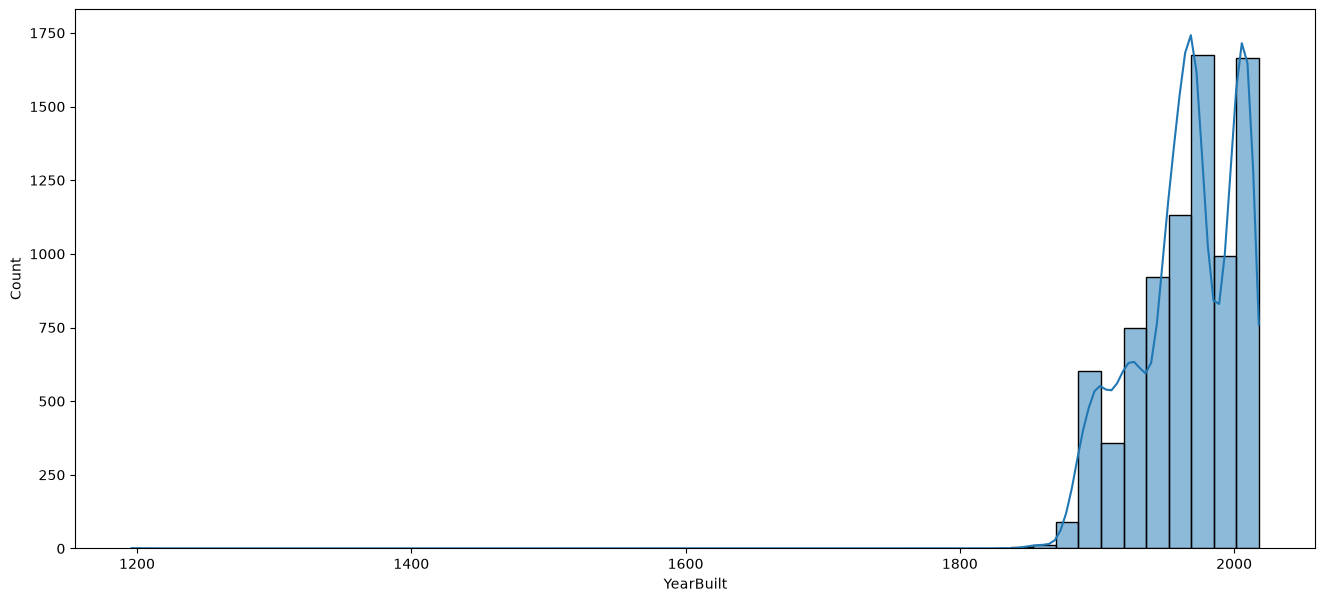

In [12]:
#plot histogram for skewness
plt.figure(figsize=(16,7))
sns.histplot(df['YearBuilt'], kde=True, edgecolor="k", bins=50)

In [13]:
#shape of the data
df.shape

(13580, 22)

In [14]:
#calculate z score for each value and make a column
df['z_yearbuilt']=(df.YearBuilt-df.YearBuilt.mean())/df.YearBuilt.std()

In [15]:
#data record which are outliers
df[df['z_yearbuilt']<-3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Count,z_yearbuilt
2079,Collingwood,2/79 Oxford St,2,u,855000.0,S,Nelson,3/09/2016,1.6,3066.0,...,2886.0,122.0,1830.0,Yarra,-37.80420,144.98450,Northern Metropolitan,4553.0,2079,-3.613379
2554,Fitzroy,11 Henry St,2,h,677000.0,S,Chambers,27/11/2016,1.6,3065.0,...,67.0,NaN,1850.0,Yarra,-37.79690,144.97590,Northern Metropolitan,5825.0,2554,-3.076808
4843,Prahran,602/220 Commercial Rd,2,u,841000.0,S,hockingstuart,18/03/2017,4.5,3181.0,...,0.0,101.0,1850.0,Stonnington,-37.84700,144.99360,Southern Metropolitan,7717.0,4843,-3.076808
5405,Richmond,22a Stanley St,3,h,1600000.0,S,Biggin,24/09/2016,2.6,3121.0,...,80.0,144.0,1850.0,Yarra,-37.82330,144.99470,Northern Metropolitan,14949.0,5405,-3.076808
5860,St Kilda,51/167 Fitzroy St,3,u,1600000.0,PI,Kay,25/02/2017,6.1,3182.0,...,0.0,3.0,1850.0,Port Phillip,-37.85840,144.98020,Southern Metropolitan,13240.0,5860,-3.076808
9968,Mount Waverley,5 Armstrong St,3,h,1200000.0,VB,McGrath,24/06/2017,14.2,3149.0,...,807.0,117.0,1196.0,Monash,-37.86788,145.12121,Eastern Metropolitan,13366.0,9968,-20.622662


In [16]:
#data record which are outliers
df[df['z_yearbuilt']>3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Count,z_yearbuilt


In [17]:
#drop rows where YearBuilt is a >3 standard-deviation outlier
df = df[(df['z_yearbuilt'] > -3) & (df['z_yearbuilt'] < 3)]
df.info()

<class 'pandas.DataFrame'>
Index: 8199 entries, 1 to 13579
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         8199 non-null   str    
 1   Address        8199 non-null   str    
 2   Rooms          8199 non-null   int64  
 3   Type           8199 non-null   str    
 4   Price          8199 non-null   float64
 5   Method         8199 non-null   str    
 6   SellerG        8199 non-null   str    
 7   Date           8199 non-null   str    
 8   Distance       8199 non-null   float64
 9   Postcode       8199 non-null   float64
 10  Bedroom2       8199 non-null   float64
 11  Bathroom       8199 non-null   float64
 12  Car            8168 non-null   float64
 13  Landsize       8199 non-null   float64
 14  BuildingArea   6853 non-null   float64
 15  YearBuilt      8199 non-null   float64
 16  CouncilArea    7442 non-null   str    
 17  Lattitude      8199 non-null   float64
 18  Longtitude     8199 non

<Axes: xlabel='YearBuilt', ylabel='Count'>

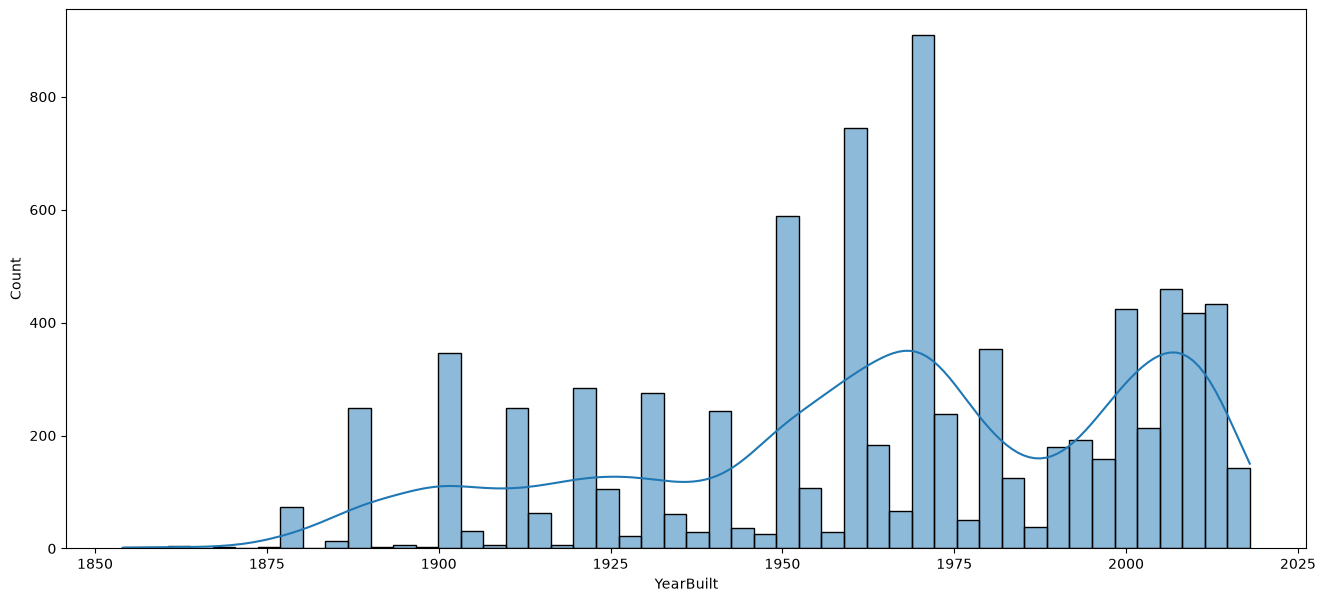

In [18]:
#histogram after removal of outliers
plt.figure(figsize=(16,7))
sns.histplot(df['YearBuilt'], kde=True, edgecolor="k", bins=50)

### OUTLIERS FOR ROOMS COLUMN

In [19]:
#CALCUTE Z SCORE FOR ROOMS DATA COLUMMN
df['z_rooms']=(df.Rooms-df.Rooms.mean())/df.Rooms.std()

In [20]:
#find outliers
df[df['z_rooms']<-3]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Count,z_yearbuilt,z_rooms


In [21]:
#find outliers
room_outliers=(df[df['z_rooms']>3.5])
room_outliers

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Count,z_yearbuilt,z_rooms
379,Ashburton,115 Ashburn Gr,8,h,2950000.0,S,hockingstuart,10/09/2016,11.0,3147.0,...,618.00,2009.0,Boroondara,-37.87290,145.07880,Southern Metropolitan,3052.0,379,1.188927,5.169190
636,Balwyn North,2 Tudor Ct,7,h,2600000.0,PI,Barry,14/05/2016,9.2,3104.0,...,529.00,2008.0,Boroondara,-37.78980,145.09670,Southern Metropolitan,7809.0,636,1.162098,4.148548
707,Bentleigh,143 Patterson Rd,7,h,1005000.0,S,Ray,4/06/2016,13.0,3204.0,...,NaN,1950.0,Glen Eira,-37.92690,145.04700,Southern Metropolitan,6795.0,707,-0.393956,4.148548
1417,Brunswick West,2 Henderson St,7,h,1205000.0,S,Raine,15/10/2016,5.9,3055.0,...,287.00,1982.0,Moreland,-37.76340,144.94030,Northern Metropolitan,7082.0,1417,0.464557,4.148548
3255,Heidelberg Heights,478 Waterdale Rd,8,h,770000.0,VB,Miles,19/11/2016,10.5,3081.0,...,115.00,1960.0,Banyule,-37.74260,145.04800,Eastern Metropolitan,2947.0,3255,-0.125671,5.169190
4285,Newport,487 Melbourne Rd,8,h,881000.0,S,Jas,30/07/2016,8.4,3015.0,...,190.00,1920.0,Hobsons Bay,-37.83850,144.88240,Western Metropolitan,5498.0,4285,-1.198812,5.169190
6881,Essendon West,6 Sapphire St,7,h,1300000.0,PI,Nelson,19/11/2016,9.8,3040.0,...,316.00,1970.0,Moonee Valley,-37.75000,144.88580,Western Metropolitan,588.0,6881,0.142615,4.148548
8793,Donvale,1 Bernarra Ct,7,h,2705000.0,S,Ray,1/07/2017,16.1,3111.0,...,409.54,2004.0,Manningham,-37.76598,145.19329,Eastern Metropolitan,4790.0,8793,1.054784,4.148548
10177,Burwood,11 McComas Gr,7,h,1642000.0,S,Buxton,27/05/2017,10.4,3125.0,...,146.00,1950.0,Whitehorse,-37.85103,145.11232,Southern Metropolitan,5678.0,10177,-0.393956,4.148548
11207,Strathmore,78 Bulla Rd,7,h,2000000.0,SP,Nelson,12/08/2017,8.2,3041.0,...,355.00,1999.0,Moonee Valley,-37.73681,144.90587,Western Metropolitan,3284.0,11207,0.920642,4.148548


In [22]:
#remove outliers from rooms column
df_no_outliers=df[(df.z_rooms>-3) &(df.z_rooms<3)]
df=df_no_outliers
df.info()

<class 'pandas.DataFrame'>
Index: 8150 entries, 1 to 13579
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         8150 non-null   str    
 1   Address        8150 non-null   str    
 2   Rooms          8150 non-null   int64  
 3   Type           8150 non-null   str    
 4   Price          8150 non-null   float64
 5   Method         8150 non-null   str    
 6   SellerG        8150 non-null   str    
 7   Date           8150 non-null   str    
 8   Distance       8150 non-null   float64
 9   Postcode       8150 non-null   float64
 10  Bedroom2       8150 non-null   float64
 11  Bathroom       8150 non-null   float64
 12  Car            8119 non-null   float64
 13  Landsize       8150 non-null   float64
 14  BuildingArea   6810 non-null   float64
 15  YearBuilt      8150 non-null   float64
 16  CouncilArea    7399 non-null   str    
 17  Lattitude      8150 non-null   float64
 18  Longtitude     8150 non

In [23]:
#drop the z score columns
df=df.drop('z_yearbuilt',axis=1)
df=df.drop('z_rooms',axis=1)
df.info()

<class 'pandas.DataFrame'>
Index: 8150 entries, 1 to 13579
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         8150 non-null   str    
 1   Address        8150 non-null   str    
 2   Rooms          8150 non-null   int64  
 3   Type           8150 non-null   str    
 4   Price          8150 non-null   float64
 5   Method         8150 non-null   str    
 6   SellerG        8150 non-null   str    
 7   Date           8150 non-null   str    
 8   Distance       8150 non-null   float64
 9   Postcode       8150 non-null   float64
 10  Bedroom2       8150 non-null   float64
 11  Bathroom       8150 non-null   float64
 12  Car            8119 non-null   float64
 13  Landsize       8150 non-null   float64
 14  BuildingArea   6810 non-null   float64
 15  YearBuilt      8150 non-null   float64
 16  CouncilArea    7399 non-null   str    
 17  Lattitude      8150 non-null   float64
 18  Longtitude     8150 non

### REMOVE THE DUPLICATE VALUES IN ADDRESS COLUMN

In [24]:
#dataframe with duplicate values of address.
duplicate = df[df['Address'].duplicated()]
duplicate

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Count
40,Airport West,50 Bedford St,3,h,770000.0,SP,Nelson,4/03/2017,13.5,3042.0,...,1.0,0.0,145.0,1965.0,Moonee Valley,-37.72030,144.87550,Western Metropolitan,3464.0,40
575,Balwyn,112 Belmore Rd,5,h,3020000.0,PI,Jellis,28/05/2016,9.7,3103.0,...,2.0,715.0,420.0,2009.0,Boroondara,-37.80280,145.07680,Southern Metropolitan,5682.0,575
615,Balwyn North,3 Clive Ct,4,h,2130000.0,PI,RW,8/10/2016,9.2,3104.0,...,2.0,1274.0,275.0,1970.0,Boroondara,-37.78220,145.09070,Southern Metropolitan,7809.0,615
667,Balwyn North,41 Helston St,4,h,1900000.0,VB,One,22/08/2016,9.2,3104.0,...,4.0,587.0,165.0,1960.0,Boroondara,-37.78410,145.09530,Southern Metropolitan,7809.0,667
684,Balwyn North,15 Ellendale St,3,h,1038000.0,S,Christopher,28/05/2016,9.2,3104.0,...,1.0,207.0,144.0,2003.0,Boroondara,-37.78930,145.09200,Southern Metropolitan,7809.0,684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13250,Northcote,19 Charles St,3,h,1360000.0,SP,McGrath,23/09/2017,5.3,3070.0,...,1.0,184.0,NaN,1910.0,NaN,-37.77651,144.99074,Northern Metropolitan,11364.0,13250
13296,St Kilda,20 Fawkner St,4,h,2680000.0,S,Marshall,23/09/2017,5.0,3182.0,...,1.0,324.0,265.0,1890.0,NaN,-37.86569,144.97919,Southern Metropolitan,13240.0,13296
13371,Brighton East,375 South Rd,5,h,1650000.0,SP,Hodges,26/08/2017,10.3,3187.0,...,5.0,773.0,275.0,1950.0,NaN,-37.93203,145.02844,Southern Metropolitan,6938.0,13371
13421,Footscray,39 Moore St,3,h,755000.0,PI,hockingstuart,26/08/2017,5.1,3011.0,...,2.0,334.0,110.0,1920.0,NaN,-37.79770,144.90398,Western Metropolitan,7570.0,13421


In [25]:
#drop the columns with duplicate values
df=df.drop_duplicates(subset=['Address'])
df.info()

<class 'pandas.DataFrame'>
Index: 8048 entries, 1 to 13579
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         8048 non-null   str    
 1   Address        8048 non-null   str    
 2   Rooms          8048 non-null   int64  
 3   Type           8048 non-null   str    
 4   Price          8048 non-null   float64
 5   Method         8048 non-null   str    
 6   SellerG        8048 non-null   str    
 7   Date           8048 non-null   str    
 8   Distance       8048 non-null   float64
 9   Postcode       8048 non-null   float64
 10  Bedroom2       8048 non-null   float64
 11  Bathroom       8048 non-null   float64
 12  Car            8018 non-null   float64
 13  Landsize       8048 non-null   float64
 14  BuildingArea   6719 non-null   float64
 15  YearBuilt      8048 non-null   float64
 16  CouncilArea    7307 non-null   str    
 17  Lattitude      8048 non-null   float64
 18  Longtitude     8048 non

### EXPLORE THE CATEGORICAL FEATURES

In [26]:
#unique region names
df['Regionname'].unique()

<StringArray>
[     'Northern Metropolitan',       'Western Metropolitan',
      'Southern Metropolitan',       'Eastern Metropolitan',
 'South-Eastern Metropolitan',          'Northern Victoria',
           'Eastern Victoria',           'Western Victoria']
Length: 8, dtype: str

In [27]:
#unique type of houses
df['Type'].unique()

<StringArray>
['h', 'u', 't']
Length: 3, dtype: str

### EXAMINING FEATURES WITH SIMILAR VALUES

In [28]:
# Examine Rooms v Bedroom2, if the difference comes to be zero it means the data is similar
df['Rooms v Bedroom2'] = df['Rooms'] - df['Bedroom2']

In [29]:
#dropping the Bedroom2 feature
df = df.drop(columns=['Bedroom2','Rooms v Bedroom2'])

In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 8048 entries, 1 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         8048 non-null   str    
 1   Address        8048 non-null   str    
 2   Rooms          8048 non-null   int64  
 3   Type           8048 non-null   str    
 4   Price          8048 non-null   float64
 5   Method         8048 non-null   str    
 6   SellerG        8048 non-null   str    
 7   Date           8048 non-null   str    
 8   Distance       8048 non-null   float64
 9   Postcode       8048 non-null   float64
 10  Bathroom       8048 non-null   float64
 11  Car            8018 non-null   float64
 12  Landsize       8048 non-null   float64
 13  BuildingArea   6719 non-null   float64
 14  YearBuilt      8048 non-null   float64
 15  CouncilArea    7307 non-null   str    
 16  Lattitude      8048 non-null   float64
 17  Longtitude     8048 non-null   float64
 18  Regionname     8048 non

# HANDLING MISSING VALUES

In [31]:
#find the null values 
df.isnull().sum()

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bathroom            0
Car                30
Landsize            0
BuildingArea     1329
YearBuilt           0
CouncilArea       741
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
Count               0
dtype: int64

In [32]:
#dropping feature: one of the options to deal with missing data
df=df.drop('BuildingArea',axis=1)
df.info()

<class 'pandas.DataFrame'>
Index: 8048 entries, 1 to 13579
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         8048 non-null   str    
 1   Address        8048 non-null   str    
 2   Rooms          8048 non-null   int64  
 3   Type           8048 non-null   str    
 4   Price          8048 non-null   float64
 5   Method         8048 non-null   str    
 6   SellerG        8048 non-null   str    
 7   Date           8048 non-null   str    
 8   Distance       8048 non-null   float64
 9   Postcode       8048 non-null   float64
 10  Bathroom       8048 non-null   float64
 11  Car            8018 non-null   float64
 12  Landsize       8048 non-null   float64
 13  YearBuilt      8048 non-null   float64
 14  CouncilArea    7307 non-null   str    
 15  Lattitude      8048 non-null   float64
 16  Longtitude     8048 non-null   float64
 17  Regionname     8048 non-null   str    
 18  Propertycount  8048 non

## Linear Regression Imputation


In [33]:
#dataframe to create linear regression model.
_houses = df.loc[(df['YearBuilt'].notnull())]
_houses.info()

<class 'pandas.DataFrame'>
Index: 8048 entries, 1 to 13579
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         8048 non-null   str    
 1   Address        8048 non-null   str    
 2   Rooms          8048 non-null   int64  
 3   Type           8048 non-null   str    
 4   Price          8048 non-null   float64
 5   Method         8048 non-null   str    
 6   SellerG        8048 non-null   str    
 7   Date           8048 non-null   str    
 8   Distance       8048 non-null   float64
 9   Postcode       8048 non-null   float64
 10  Bathroom       8048 non-null   float64
 11  Car            8018 non-null   float64
 12  Landsize       8048 non-null   float64
 13  YearBuilt      8048 non-null   float64
 14  CouncilArea    7307 non-null   str    
 15  Lattitude      8048 non-null   float64
 16  Longtitude     8048 non-null   float64
 17  Regionname     8048 non-null   str    
 18  Propertycount  8048 non

In [34]:
#exploring the correlation in the _houses
_houses.corr(numeric_only=True)

,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,YearBuilt,Lattitude,Longtitude,Propertycount,Count
Rooms,1.000000,0.530540,0.307375,0.063646,0.608753,0.425099,0.075905,-0.068052,0.013625,0.093946,-0.100109,0.093158
Price,0.530540,1.000000,-0.154763,0.109348,0.492840,0.254503,0.064570,-0.333367,-0.212444,0.202476,-0.052930,-0.076255
Distance,0.307375,-0.154763,1.000000,0.426185,0.131709,0.266960,0.052729,0.251737,-0.105434,0.218815,-0.069221,0.299814
Postcode,0.063646,0.109348,0.426185,1.000000,0.111720,0.043758,0.034245,0.035850,-0.399423,0.435462,0.056404,0.094724
Bathroom,0.608753,0.492840,0.131709,0.111720,1.000000,0.335533,0.079837,0.160302,-0.068745,0.116786,-0.060426,0.040854
Car,0.425099,0.254503,0.266960,0.043758,0.335533,1.000000,0.102083,0.115935,0.009527,0.051656,-0.038475,0.088111
Landsize,0.075905,0.064570,0.052729,0.034245,0.079837,0.102083,1.000000,0.038696,0.008047,0.020636,0.004372,0.073317
YearBuilt,-0.068052,-0.333367,0.251737,0.035850,0.160302,0.115935,0.038696,1.000000,0.059992,-0.001032,0.014236,0.111998
Lattitude,0.013625,-0.212444,-0.105434,-0.399423,-0.068745,0.009527,0.008047,0.059992,1.000000,-0.357041,0.062109,0.049180
Longtitude,0.093946,0.202476,0.218815,0.435462,0.116786,0.051656,0.020636,-0.001032,-0.357041,1.000000,0.046790,0.027619


In [35]:
#create the model,find the coefficient the intercept
year_reg = linear_model.LinearRegression()
X=np.array(_houses['Distance']).reshape(-1, 1)
y=np.array(_houses['YearBuilt']).reshape(-1, 1)
year_reg.fit(X, y)
print("Linear model coefficient: ",year_reg.coef_)
print("Linear model slope: ",year_reg.intercept_)


Linear model coefficient:  [[1.53559268]]
Linear model slope:  [1949.54898609]


In [36]:
#testing the model
year_reg.predict([[13.5,]])

array([[1970.2794873]])

In [37]:
#filling the missing value, using the values from the linear regression model
df['YearBuilt']=df.apply(
    lambda df: 
            year_reg.coef_* df['Distance']+year_reg.intercept_
            if np.isnan(df['YearBuilt']) else df['YearBuilt'], axis=1)

In [38]:
#check the null values have been filled
df.isnull().sum()

Suburb             0
Address            0
Rooms              0
Type               0
Price              0
Method             0
SellerG            0
Date               0
Distance           0
Postcode           0
Bathroom           0
Car               30
Landsize           0
YearBuilt          0
CouncilArea      741
Lattitude          0
Longtitude         0
Regionname         0
Propertycount      0
Count              0
dtype: int64

###  Feature Engineering

In [39]:
# Add age variable in the dataset
df['Age'] = 2021 - df['YearBuilt']
# Identify historic homes in the dataset
df['Historic'] = np.where(df['Age']>=55,'Historic','Contemporary')

In [40]:
df.info()

<class 'pandas.DataFrame'>
Index: 8048 entries, 1 to 13579
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         8048 non-null   str    
 1   Address        8048 non-null   str    
 2   Rooms          8048 non-null   int64  
 3   Type           8048 non-null   str    
 4   Price          8048 non-null   float64
 5   Method         8048 non-null   str    
 6   SellerG        8048 non-null   str    
 7   Date           8048 non-null   str    
 8   Distance       8048 non-null   float64
 9   Postcode       8048 non-null   float64
 10  Bathroom       8048 non-null   float64
 11  Car            8018 non-null   float64
 12  Landsize       8048 non-null   float64
 13  YearBuilt      8048 non-null   float64
 14  CouncilArea    7307 non-null   str    
 15  Lattitude      8048 non-null   float64
 16  Longtitude     8048 non-null   float64
 17  Regionname     8048 non-null   str    
 18  Propertycount  8048 non

## Mean Imputation

In [41]:
#calculate the mean of the Car column
car_mean=int(df['Car'].mean())
df['Car']=df['Car'].fillna(car_mean)


In [42]:
df.isnull().sum()

Suburb             0
Address            0
Rooms              0
Type               0
Price              0
Method             0
SellerG            0
Date               0
Distance           0
Postcode           0
Bathroom           0
Car                0
Landsize           0
YearBuilt          0
CouncilArea      741
Lattitude          0
Longtitude         0
Regionname         0
Propertycount      0
Count              0
Age                0
Historic           0
dtype: int64

## Filling String data in Council Area

In [43]:
# here we have find different council area data present in the dataset
pd.unique(df['CouncilArea'])

<StringArray>
[            'Yarra',     'Moonee Valley',      'Port Phillip',
           'Darebin',       'Hobsons Bay',       'Stonnington',
        'Boroondara',            'Monash',         'Glen Eira',
        'Whitehorse',       'Maribyrnong',           'Bayside',
          'Moreland',        'Manningham',           'Banyule',
          'Kingston',          'Brimbank',         'Melbourne',
              'Hume',              'Knox',         'Maroondah',
            'Melton', 'Greater Dandenong',         'Nillumbik',
        'Whittlesea',         'Frankston',    'Macedon Ranges',
      'Yarra Ranges',             'Casey',           'Wyndham',
          'Cardinia',                 nan]
Length: 32, dtype: str

In [44]:
#check how many CouncilArea values are missing before imputation
df['CouncilArea'].isnull().sum()

np.int64(741)

In [45]:
#build a mapping from suburb to its most common (mode) council area,
#using only rows where CouncilArea is known, to use for imputing the missing values
suburb_council_map = (
    df.dropna(subset=['CouncilArea'])
      .groupby('Suburb')['CouncilArea']
      .agg(lambda s: s.mode().iat[0])
      .to_dict()
)

In [46]:
#fill missing CouncilArea using the suburb -> council area mapping built above
df['CouncilArea'] = df.apply(
    lambda row: suburb_council_map.get(row['Suburb'], row['CouncilArea'])
    if pd.isnull(row['CouncilArea']) else row['CouncilArea'],
    axis=1,
)

#confirm the imputation worked
df['CouncilArea'].isnull().sum()

np.int64(10)

# VISUALISATIONS 

<Axes: xlabel='Price', ylabel='Count'>

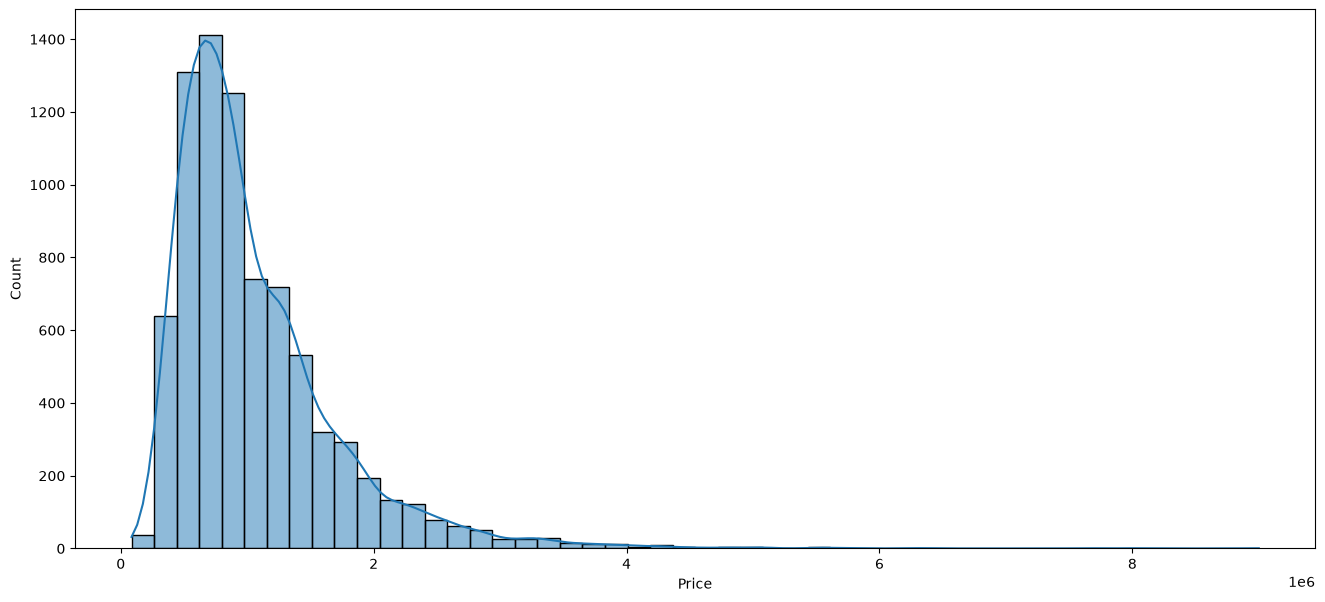

In [47]:
#histogram on the prices and its frequency
plt.figure(figsize=(16,7))
sns.histplot(df['Price'], kde=True, edgecolor="k", bins=50)

<Axes: xlabel='Car', ylabel='Count'>

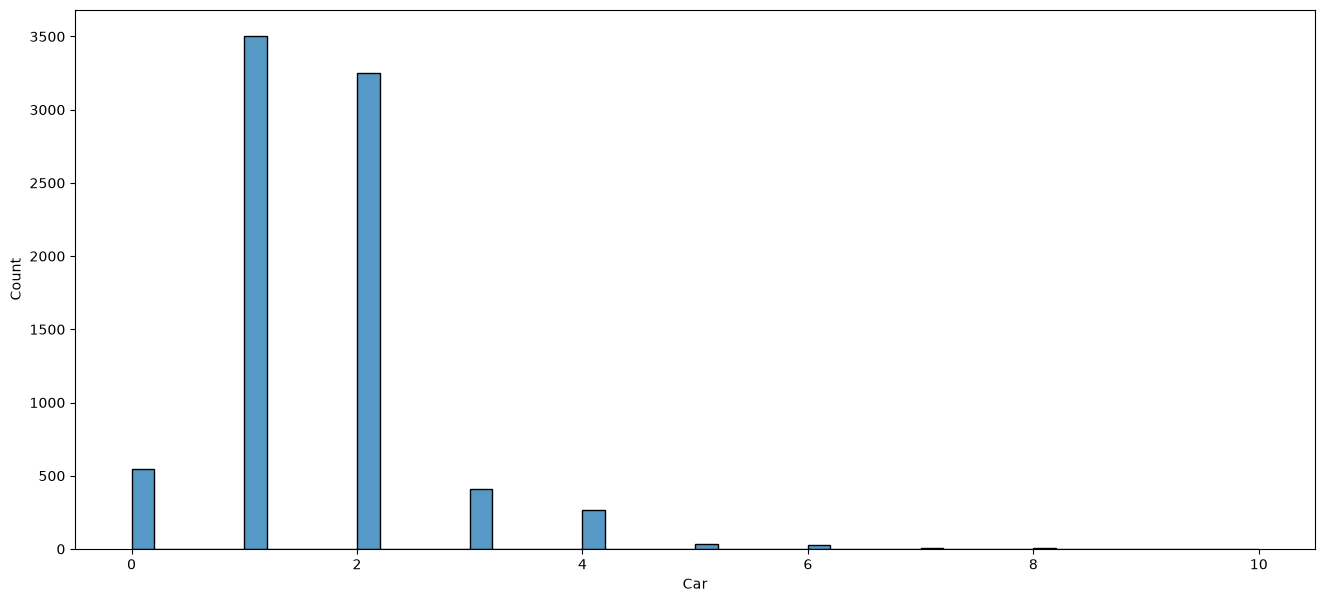

In [48]:
# car and its frequencies
plt.figure(figsize=(16,7))
sns.histplot(df['Car'], kde=False, edgecolor="k", bins=50)

<Axes: xlabel='Bathroom', ylabel='Count'>

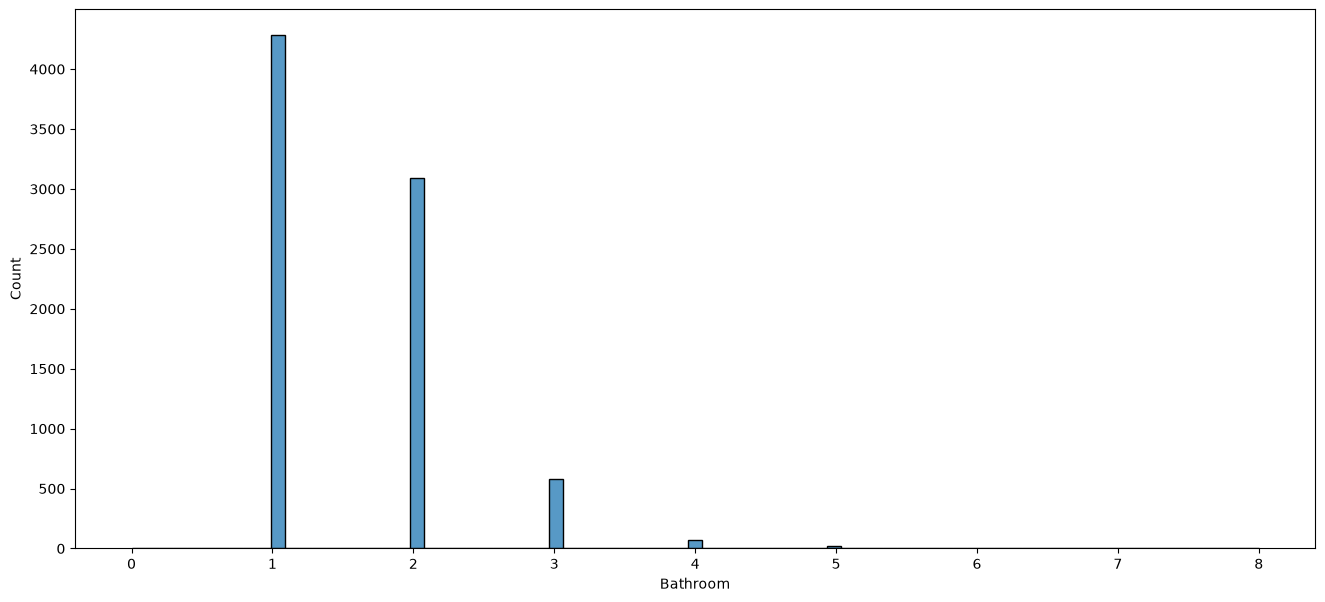

In [49]:
# bathroom frequency
plt.figure(figsize=(16,7))
sns.histplot(df['Bathroom'], kde=False, edgecolor="k")

<Axes: xlabel='Rooms', ylabel='Count'>

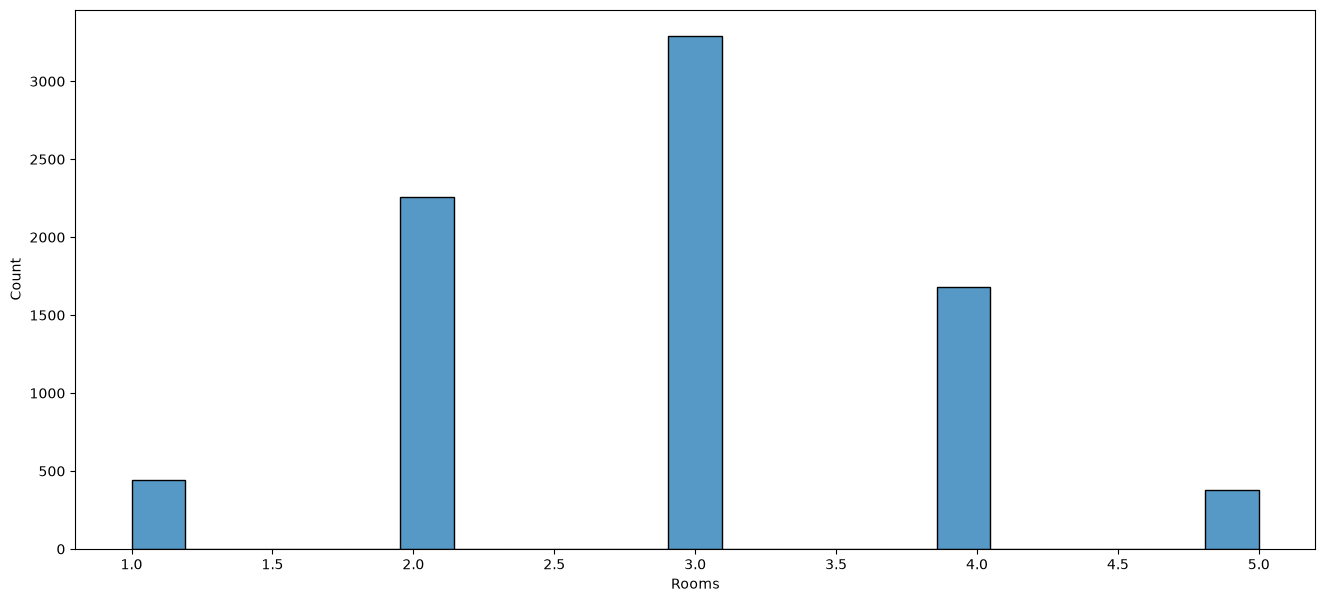

In [50]:
#rooms frequency
plt.figure(figsize=(16,7))
sns.histplot(df['Rooms'], kde=False, edgecolor="k")

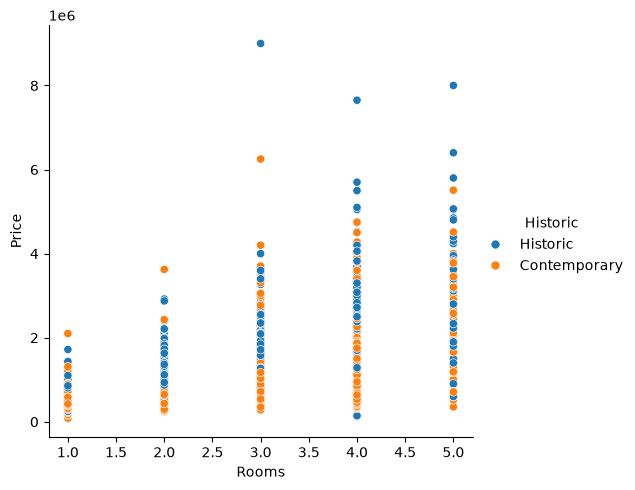

In [51]:
#rooms vs price
sns.relplot(x="Rooms",y="Price",hue='Historic',data=df)

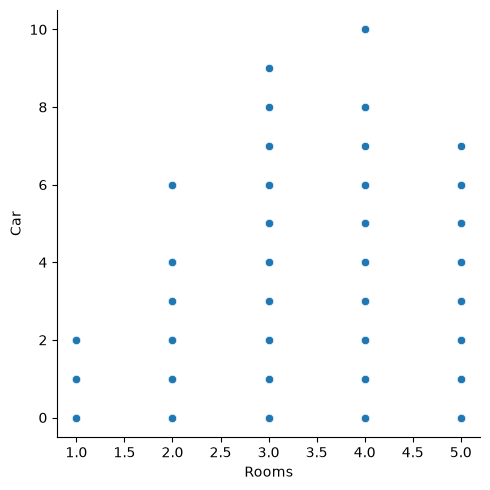

In [52]:
#rooms vs car
sns.relplot(x="Rooms",y="Car",data=df)

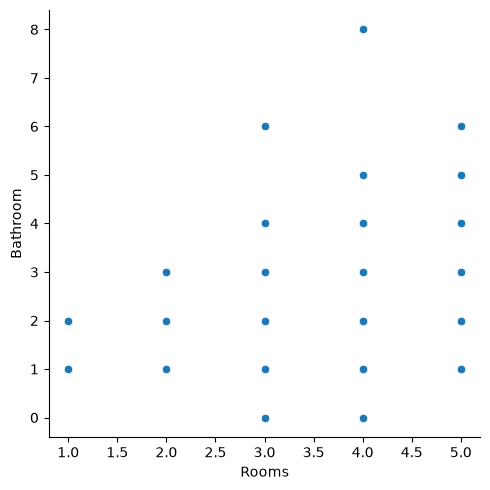

In [53]:
#rooms vs bathroom
sns.relplot(x="Rooms",y="Bathroom",data=df)

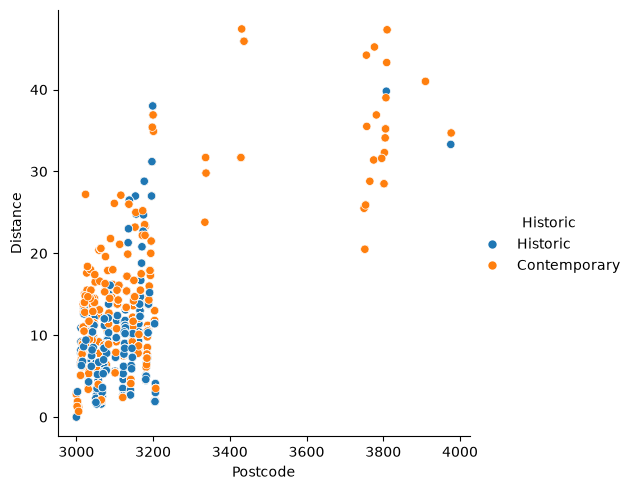

In [54]:
#postcode vs distance
sns.relplot(x="Postcode",y="Distance",hue='Historic',data=df)

### Correlation Matrix and Visualisation

In [55]:
corr=df.corr(numeric_only=True)
corr

,Rooms,Price,Distance,Postcode,Bathroom,Car,Landsize,YearBuilt,Lattitude,Longtitude,Propertycount,Count,Age
Rooms,1.000000,0.530540,0.307375,0.063646,0.608753,0.425144,0.075905,-0.068052,0.013625,0.093946,-0.100109,0.093158,0.068052
Price,0.530540,1.000000,-0.154763,0.109348,0.492840,0.252728,0.064570,-0.333367,-0.212444,0.202476,-0.052930,-0.076255,0.333367
Distance,0.307375,-0.154763,1.000000,0.426185,0.131709,0.268351,0.052729,0.251737,-0.105434,0.218815,-0.069221,0.299814,-0.251737
Postcode,0.063646,0.109348,0.426185,1.000000,0.111720,0.043223,0.034245,0.035850,-0.399423,0.435462,0.056404,0.094724,-0.035850
Bathroom,0.608753,0.492840,0.131709,0.111720,1.000000,0.335714,0.079837,0.160302,-0.068745,0.116786,-0.060426,0.040854,-0.160302
Car,0.425144,0.252728,0.268351,0.043223,0.335714,1.000000,0.101354,0.118769,0.009898,0.051858,-0.038122,0.083806,-0.118769
Landsize,0.075905,0.064570,0.052729,0.034245,0.079837,0.101354,1.000000,0.038696,0.008047,0.020636,0.004372,0.073317,-0.038696
YearBuilt,-0.068052,-0.333367,0.251737,0.035850,0.160302,0.118769,0.038696,1.000000,0.059992,-0.001032,0.014236,0.111998,-1.000000
Lattitude,0.013625,-0.212444,-0.105434,-0.399423,-0.068745,0.009898,0.008047,0.059992,1.000000,-0.357041,0.062109,0.049180,-0.059992
Longtitude,0.093946,0.202476,0.218815,0.435462,0.116786,0.051858,0.020636,-0.001032,-0.357041,1.000000,0.046790,0.027619,0.001032


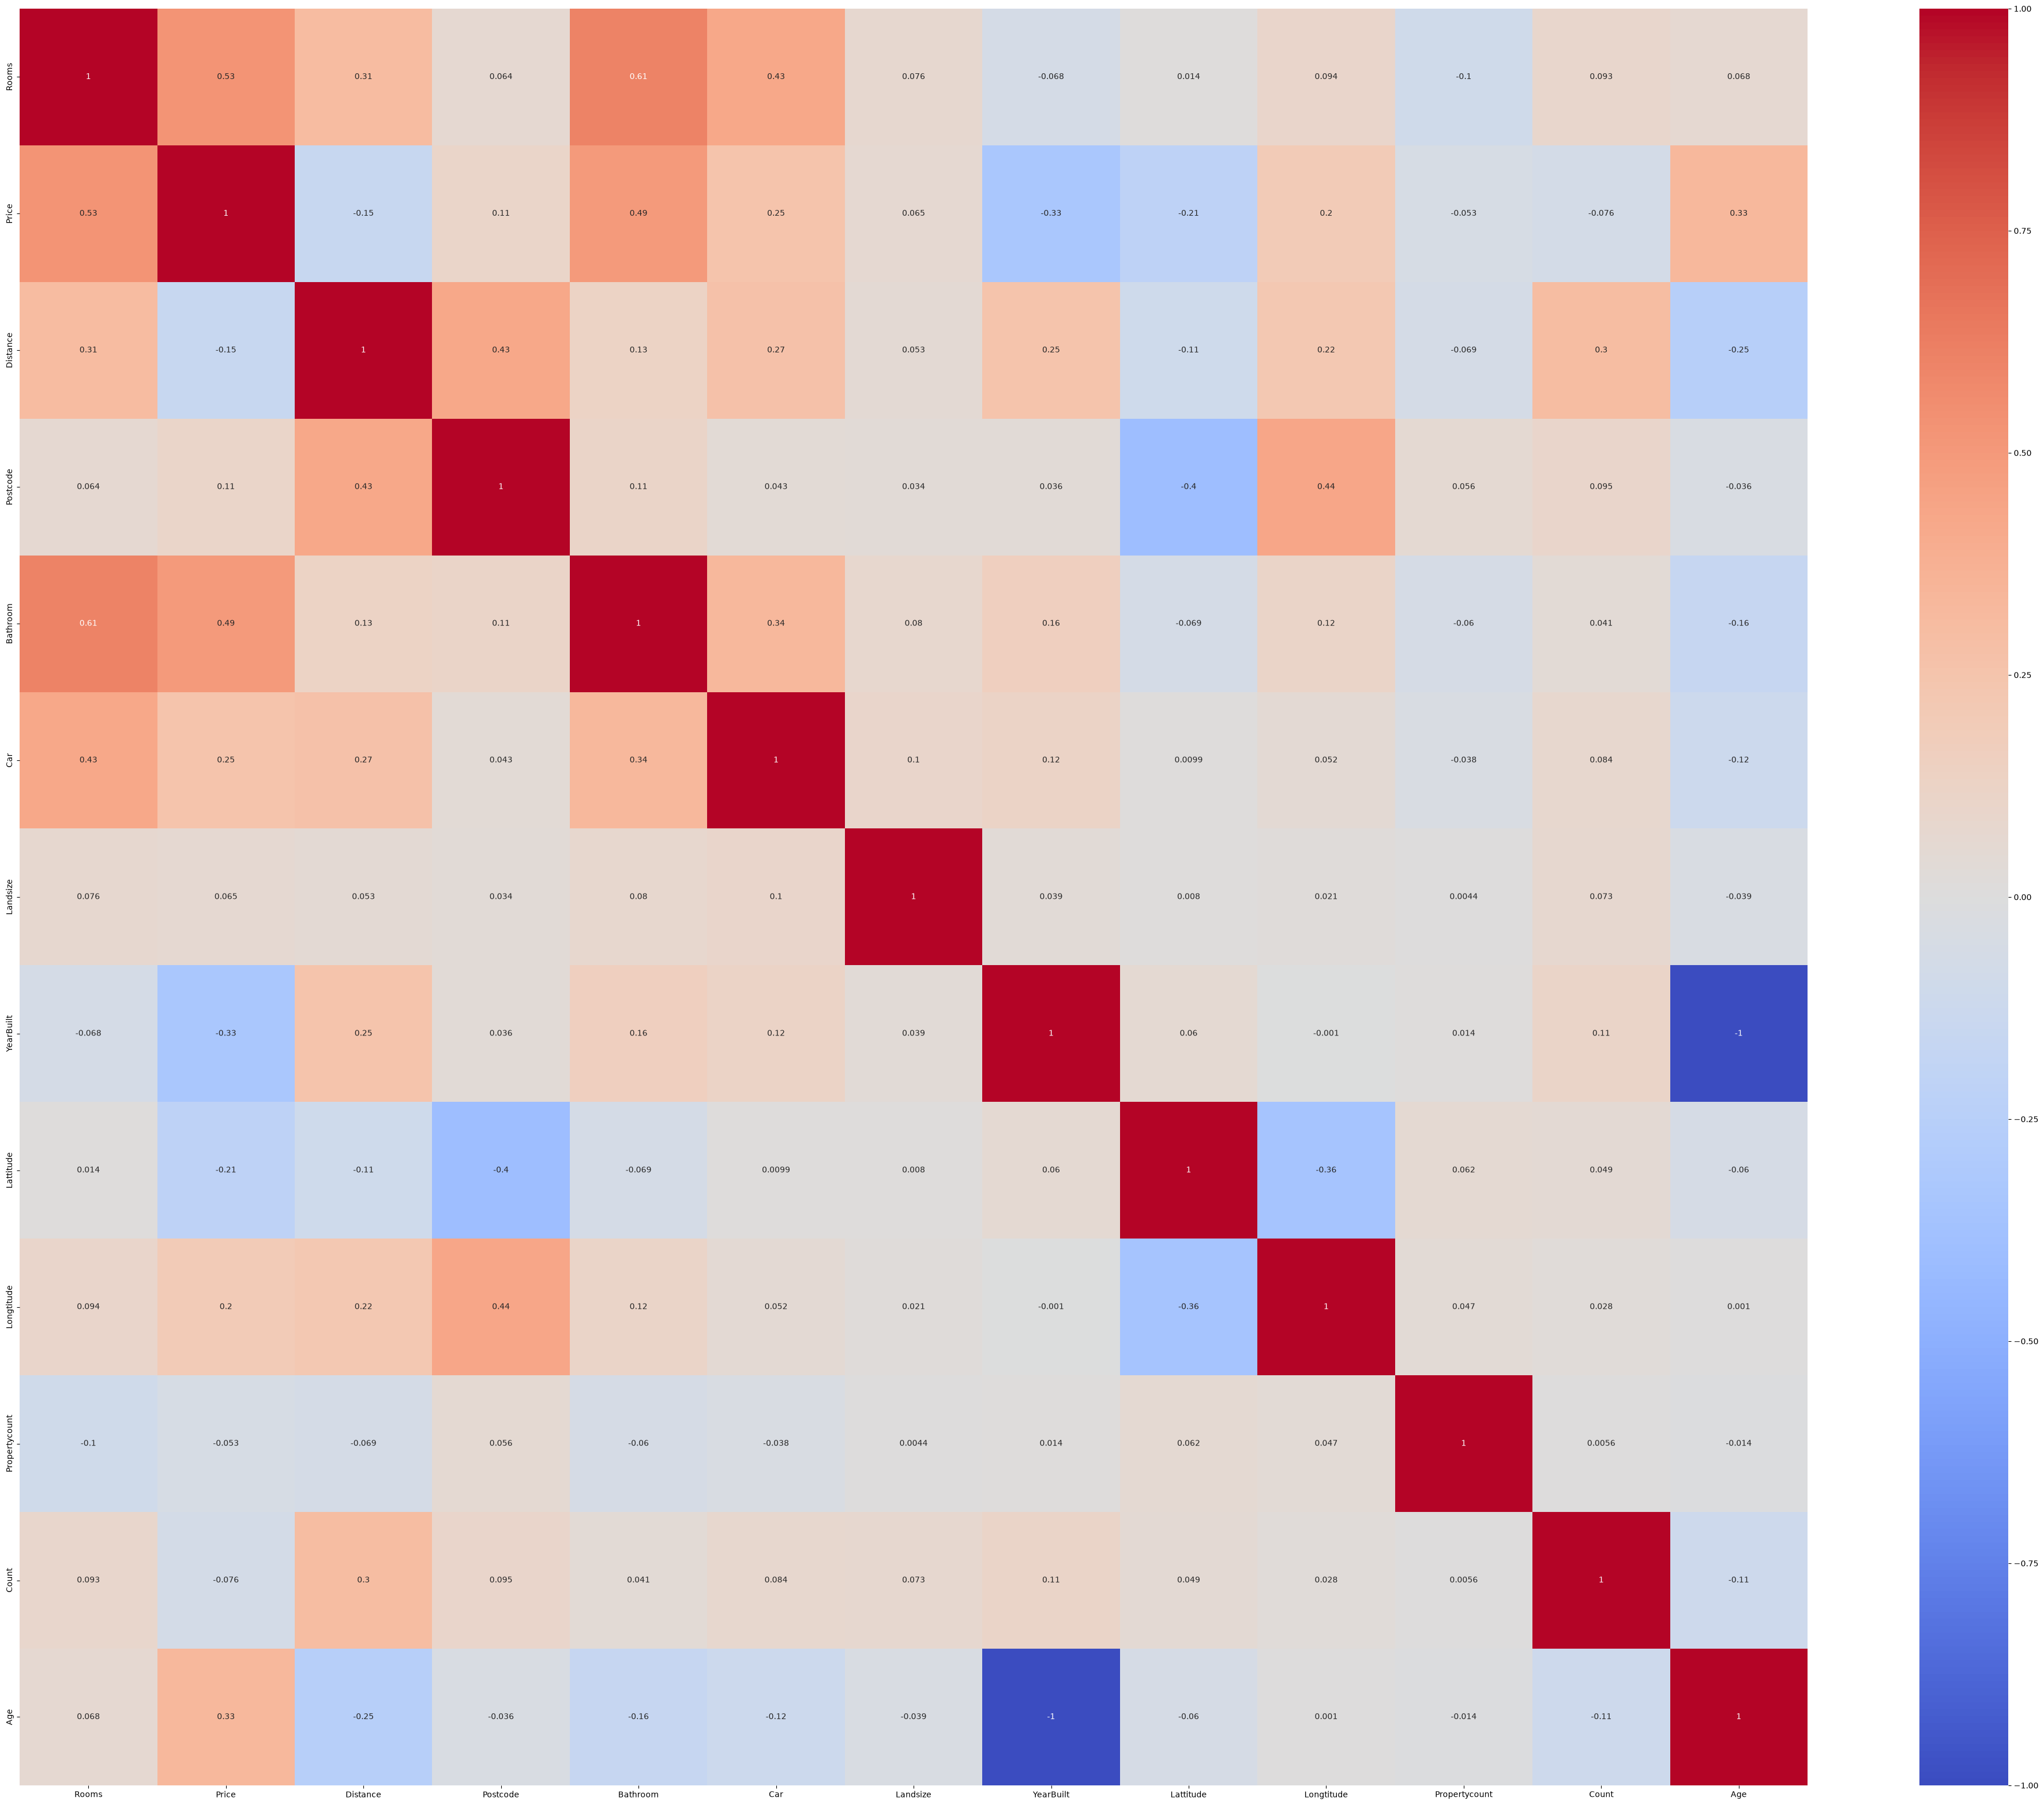

In [56]:
plt.figure(figsize=(50,40))
ax = sns.heatmap(corr, annot=True,cmap="coolwarm")

## Analyzing the categories in the dataset

In [57]:
#price feature categorisation
type_count = df.groupby("Type").count()
type_count["Type"]=["House","Townhouse","Unit"]
type_count

,Suburb,Address,Rooms,Price,Method,SellerG,Date,Distance,Postcode,Bathroom,...,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Count,Age,Historic,Type
Type,,,,,,,,,,,,,,,,,,,,,
h,5285,5285,5285,5285,5285,5285,5285,5285,5285,5285,...,5285,5275,5285,5285,5285,5285,5285,5285,5285,House
t,753,753,753,753,753,753,753,753,753,753,...,753,753,753,753,753,753,753,753,753,Townhouse
u,2010,2010,2010,2010,2010,2010,2010,2010,2010,2010,...,2010,2010,2010,2010,2010,2010,2010,2010,2010,Unit


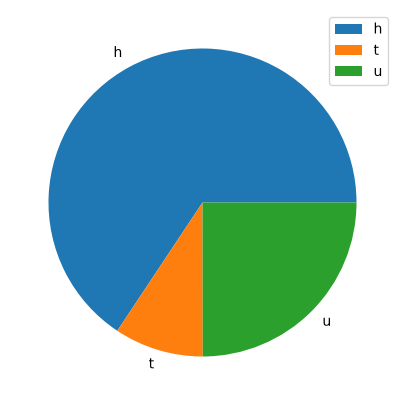

In [58]:
#pie chart
plot = type_count.plot.pie(y='Rooms', figsize=(5, 5))

In [59]:
#information about the type feature
type_mean=df.groupby("Type").mean(numeric_only=True)
type_mean['Type']=['House','Townhouse','Unit']
type_mean.info()

<class 'pandas.DataFrame'>
Index: 3 entries, h to u
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rooms          3 non-null      float64
 1   Price          3 non-null      float64
 2   Distance       3 non-null      float64
 3   Postcode       3 non-null      float64
 4   Bathroom       3 non-null      float64
 5   Car            3 non-null      float64
 6   Landsize       3 non-null      float64
 7   YearBuilt      3 non-null      float64
 8   Lattitude      3 non-null      float64
 9   Longtitude     3 non-null      float64
 10  Propertycount  3 non-null      float64
 11  Count          3 non-null      float64
 12  Age            3 non-null      float64
 13  Type           3 non-null      str    
dtypes: float64(13), str(1)
memory usage: 360.0+ bytes


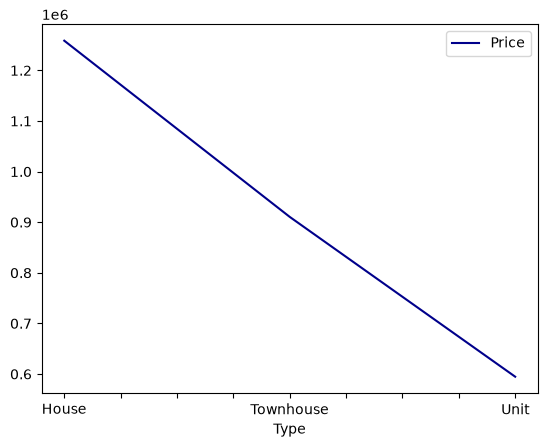

In [60]:
#line graph of mean prices 
ax = type_mean.plot.line(x='Type',y='Price',c='DarkBlue')

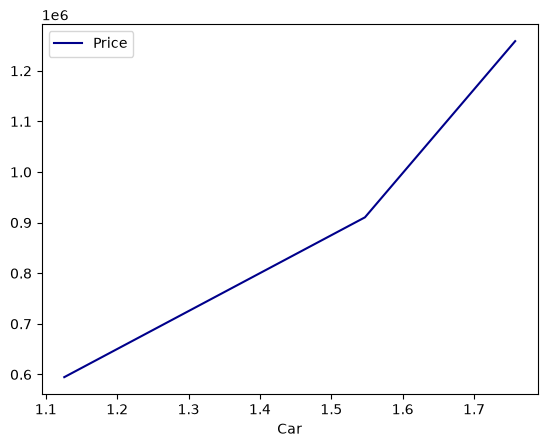

In [61]:
#car vs price in the _houses dataset
ax = type_mean.plot.line(x='Car',y='Price',c='DarkBlue')

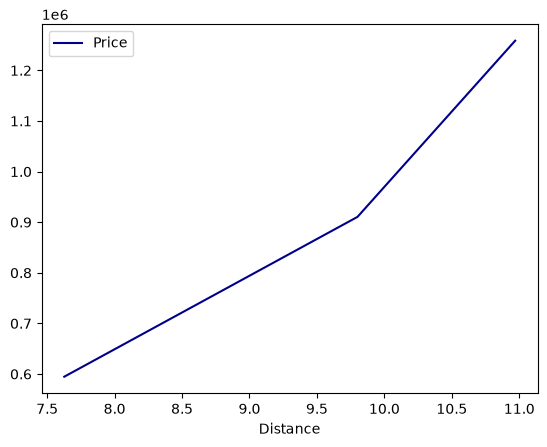

In [62]:
#distance vs price in the _houses dataset
ax = type_mean.plot.line(x='Distance',y='Price',c='DarkBlue')

# DATA FREQUENCY

In [63]:
#highest count of houses in dataset
suburb_count = df.groupby("Suburb").count().reset_index()
suburb_count.sort_values(by=['Address']).tail()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Landsize,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Count,Age,Historic
248,South Yarra,124,124,124,124,124,124,124,124,124,...,124,124,124,124,124,124,124,124,124,124
27,Bentleigh East,135,135,135,135,135,135,135,135,135,...,135,135,135,135,135,135,135,135,135,135
43,Brunswick,146,146,146,146,146,146,146,146,146,...,146,146,146,146,146,146,146,146,146,146
228,Richmond,166,166,166,166,166,166,166,166,166,...,166,166,166,166,166,166,166,166,166,166
227,Reservoir,201,201,201,201,201,201,201,201,201,...,201,201,201,201,201,201,201,201,201,201


In [64]:
#lowest count 
suburb_count.sort_values(by=['Address']).head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Landsize,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Count,Age,Historic
299,Yarra Glen,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
41,Brookfield,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
55,Campbellfield,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1
49,Burnside,1,1,1,1,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1
244,Skye,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


<Axes: xlabel='Suburb'>

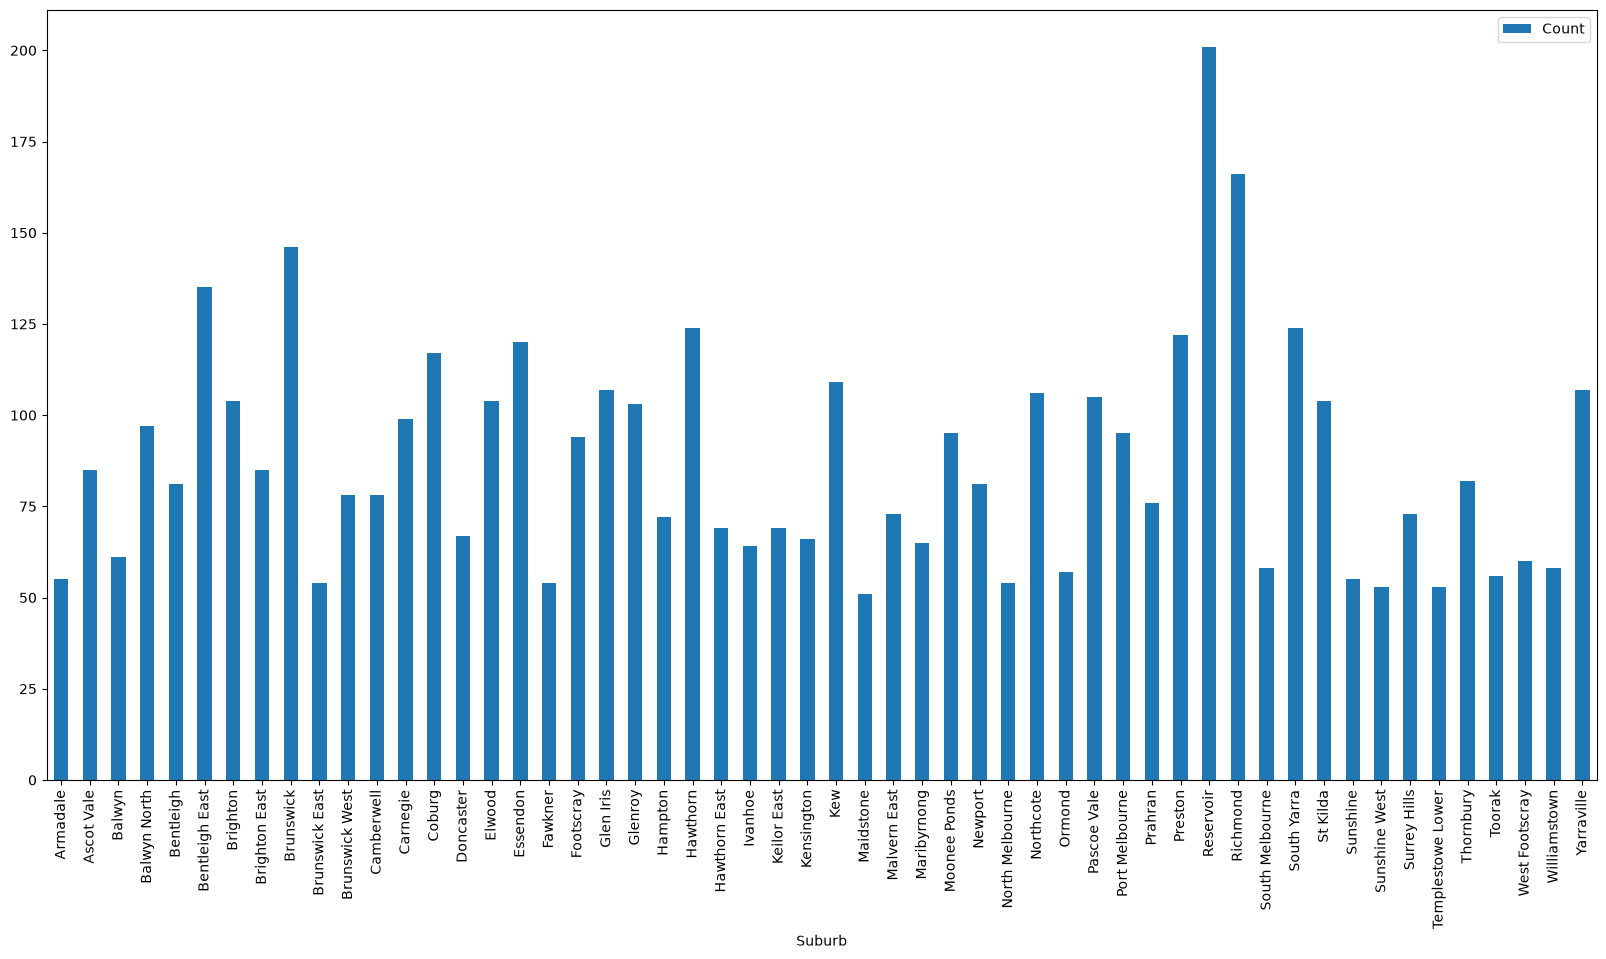

In [65]:
#high count of data records
high_count=(suburb_count.where(suburb_count['Address']>50))
high_count=high_count.dropna()
high_count['Count']=high_count['Address']

high_count.plot.bar(x='Suburb',y='Count',figsize=(20,10))

<Axes: xlabel='Suburb'>

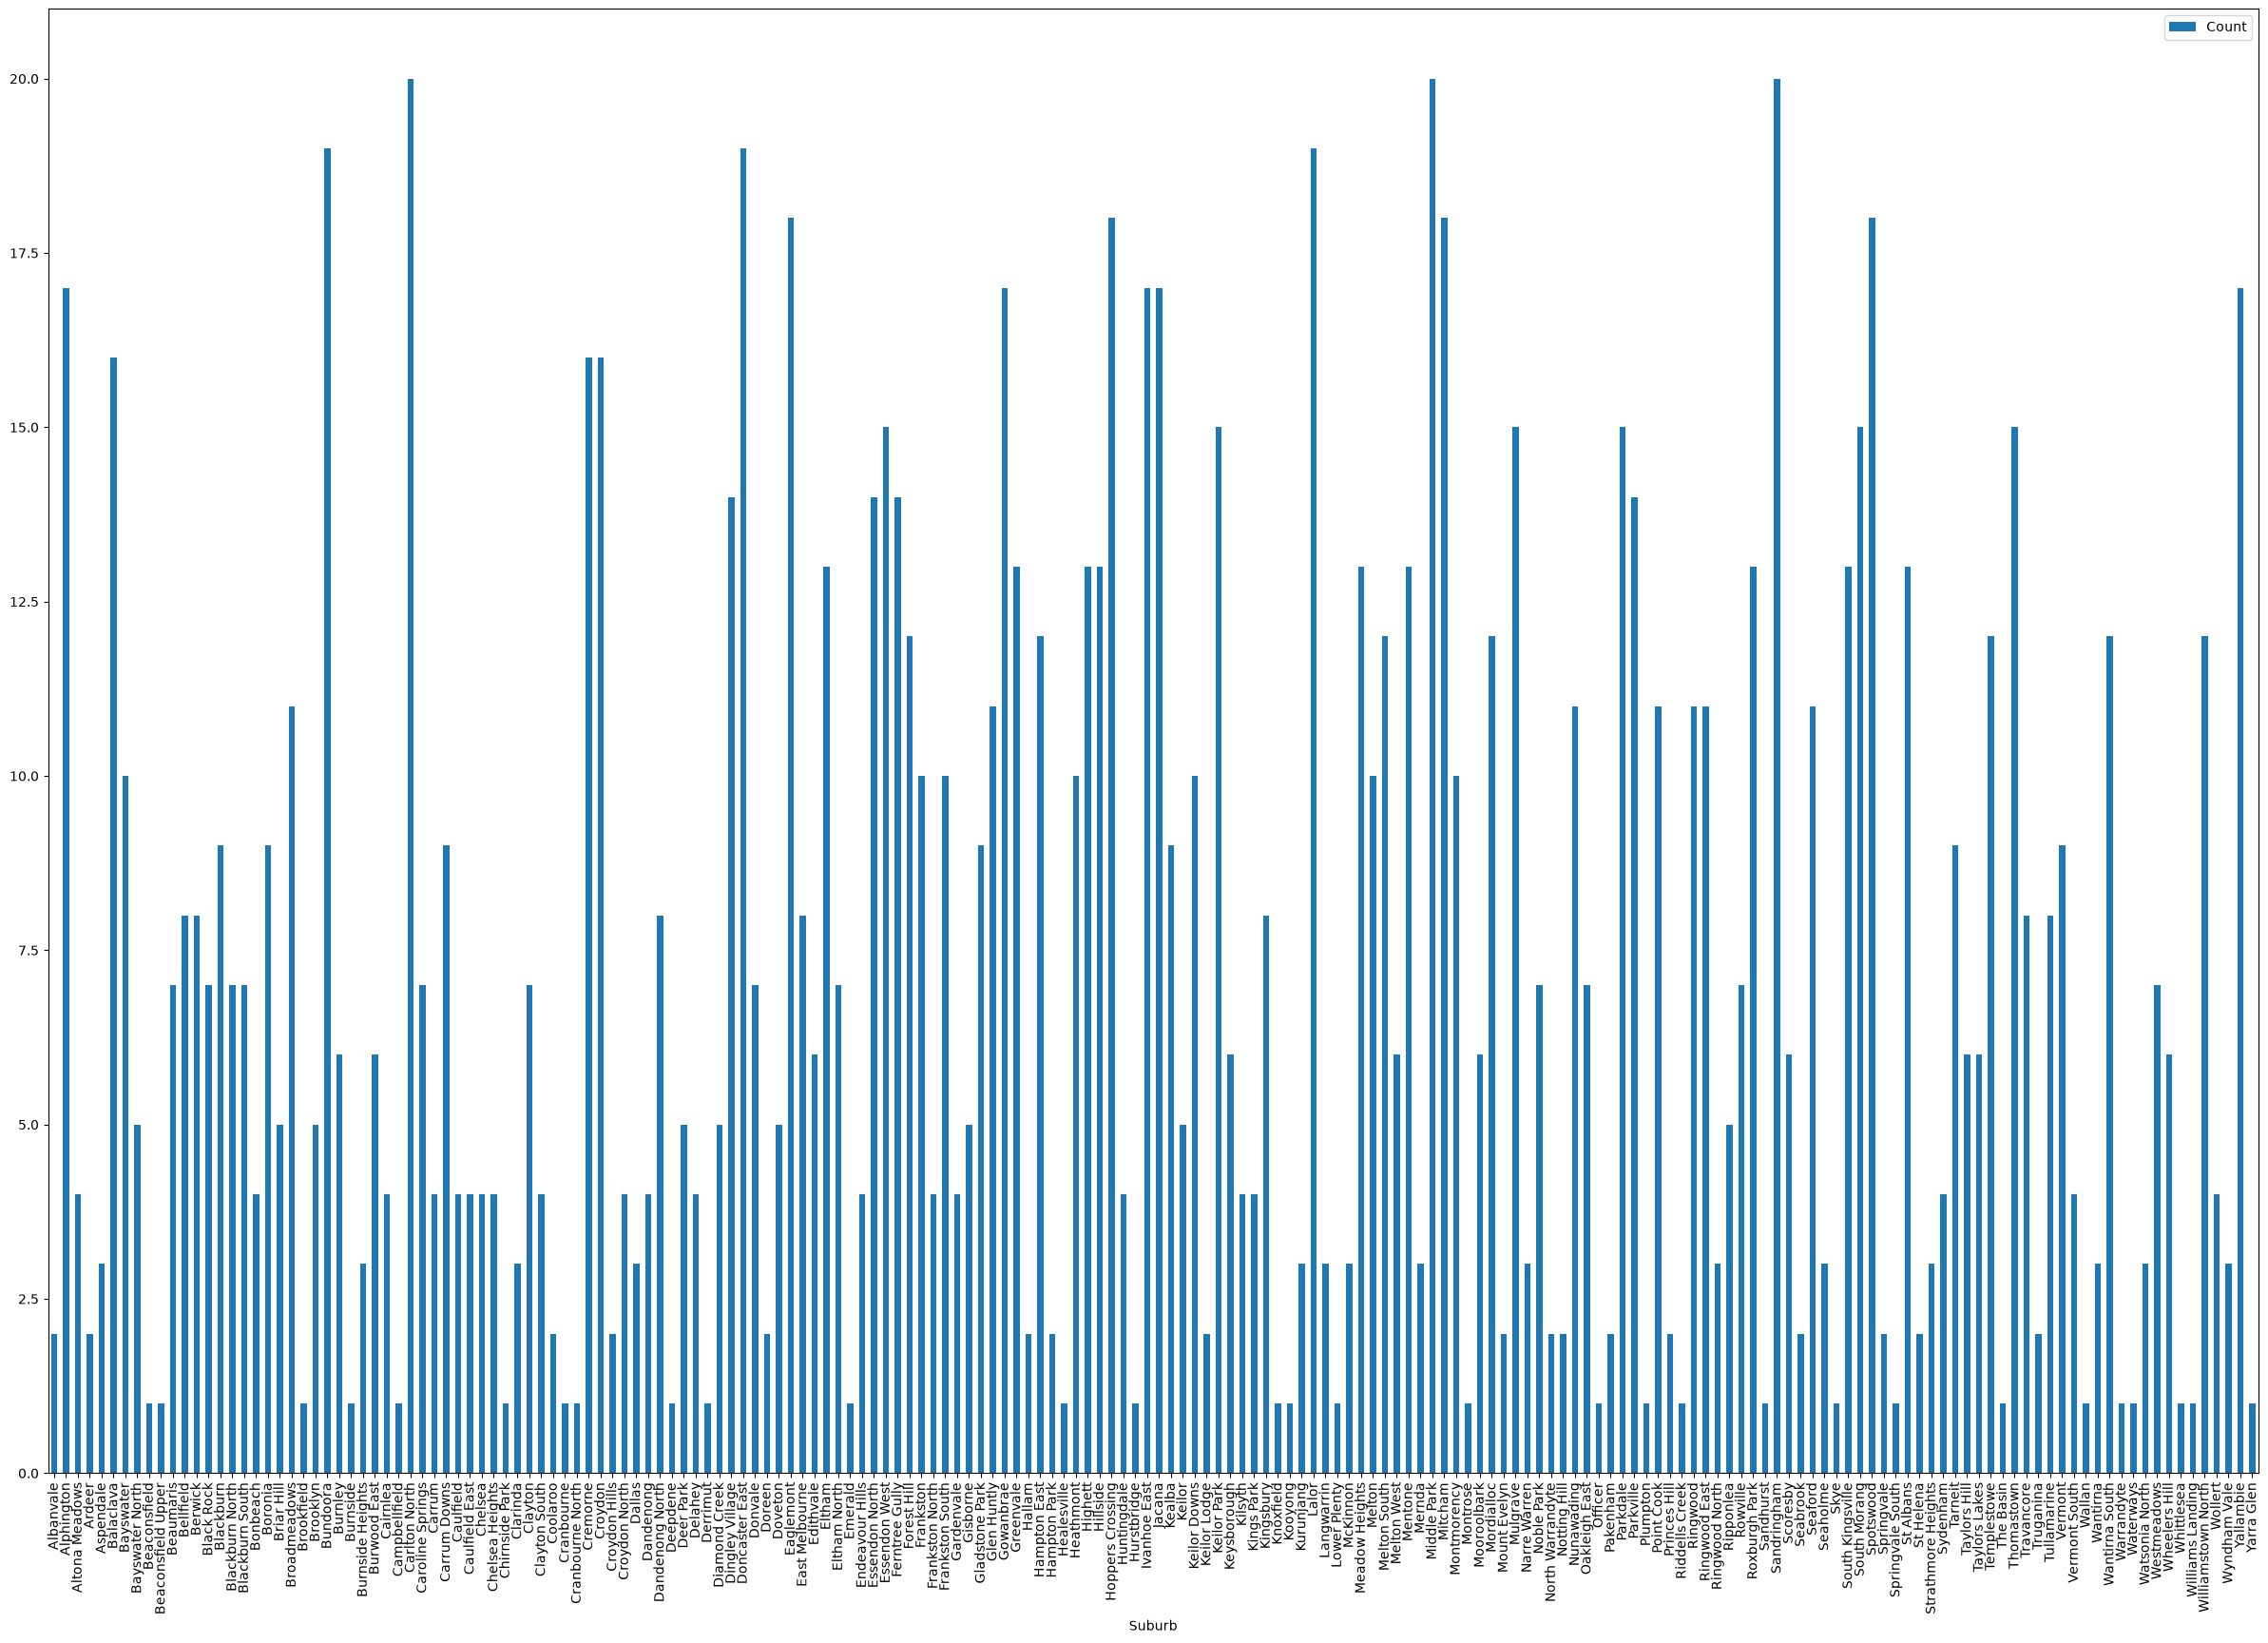

In [66]:
#low count of data records
low_count=(suburb_count.where(suburb_count['Address']<=20))
low_count=low_count.dropna()
low_count['Count']=low_count['Address']
low_count.plot.bar(x='Suburb',y='Count',figsize=(30,20))


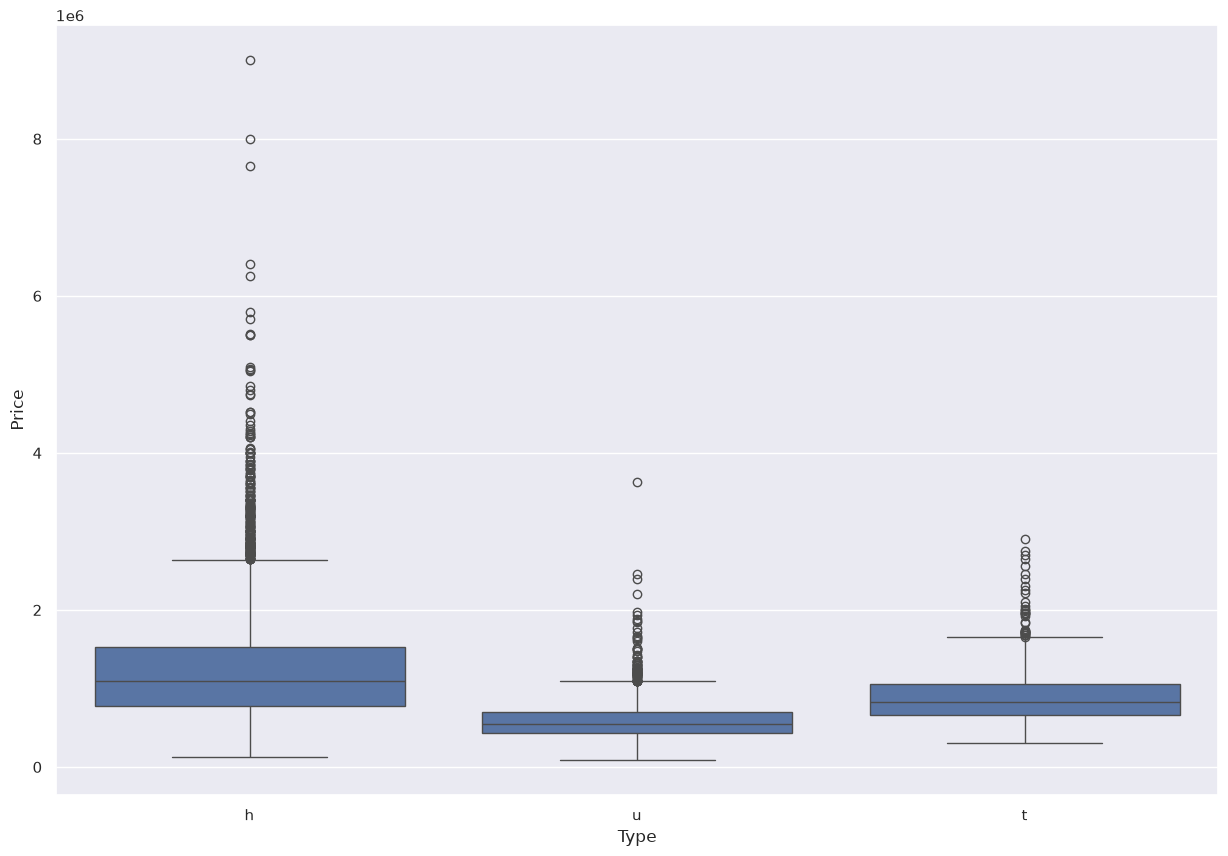

In [67]:
#boxplot on price on different types of houses
sns.set(rc={'figure.figsize':(15,10)})
ax = sns.boxplot(x="Type", y="Price", data=df)

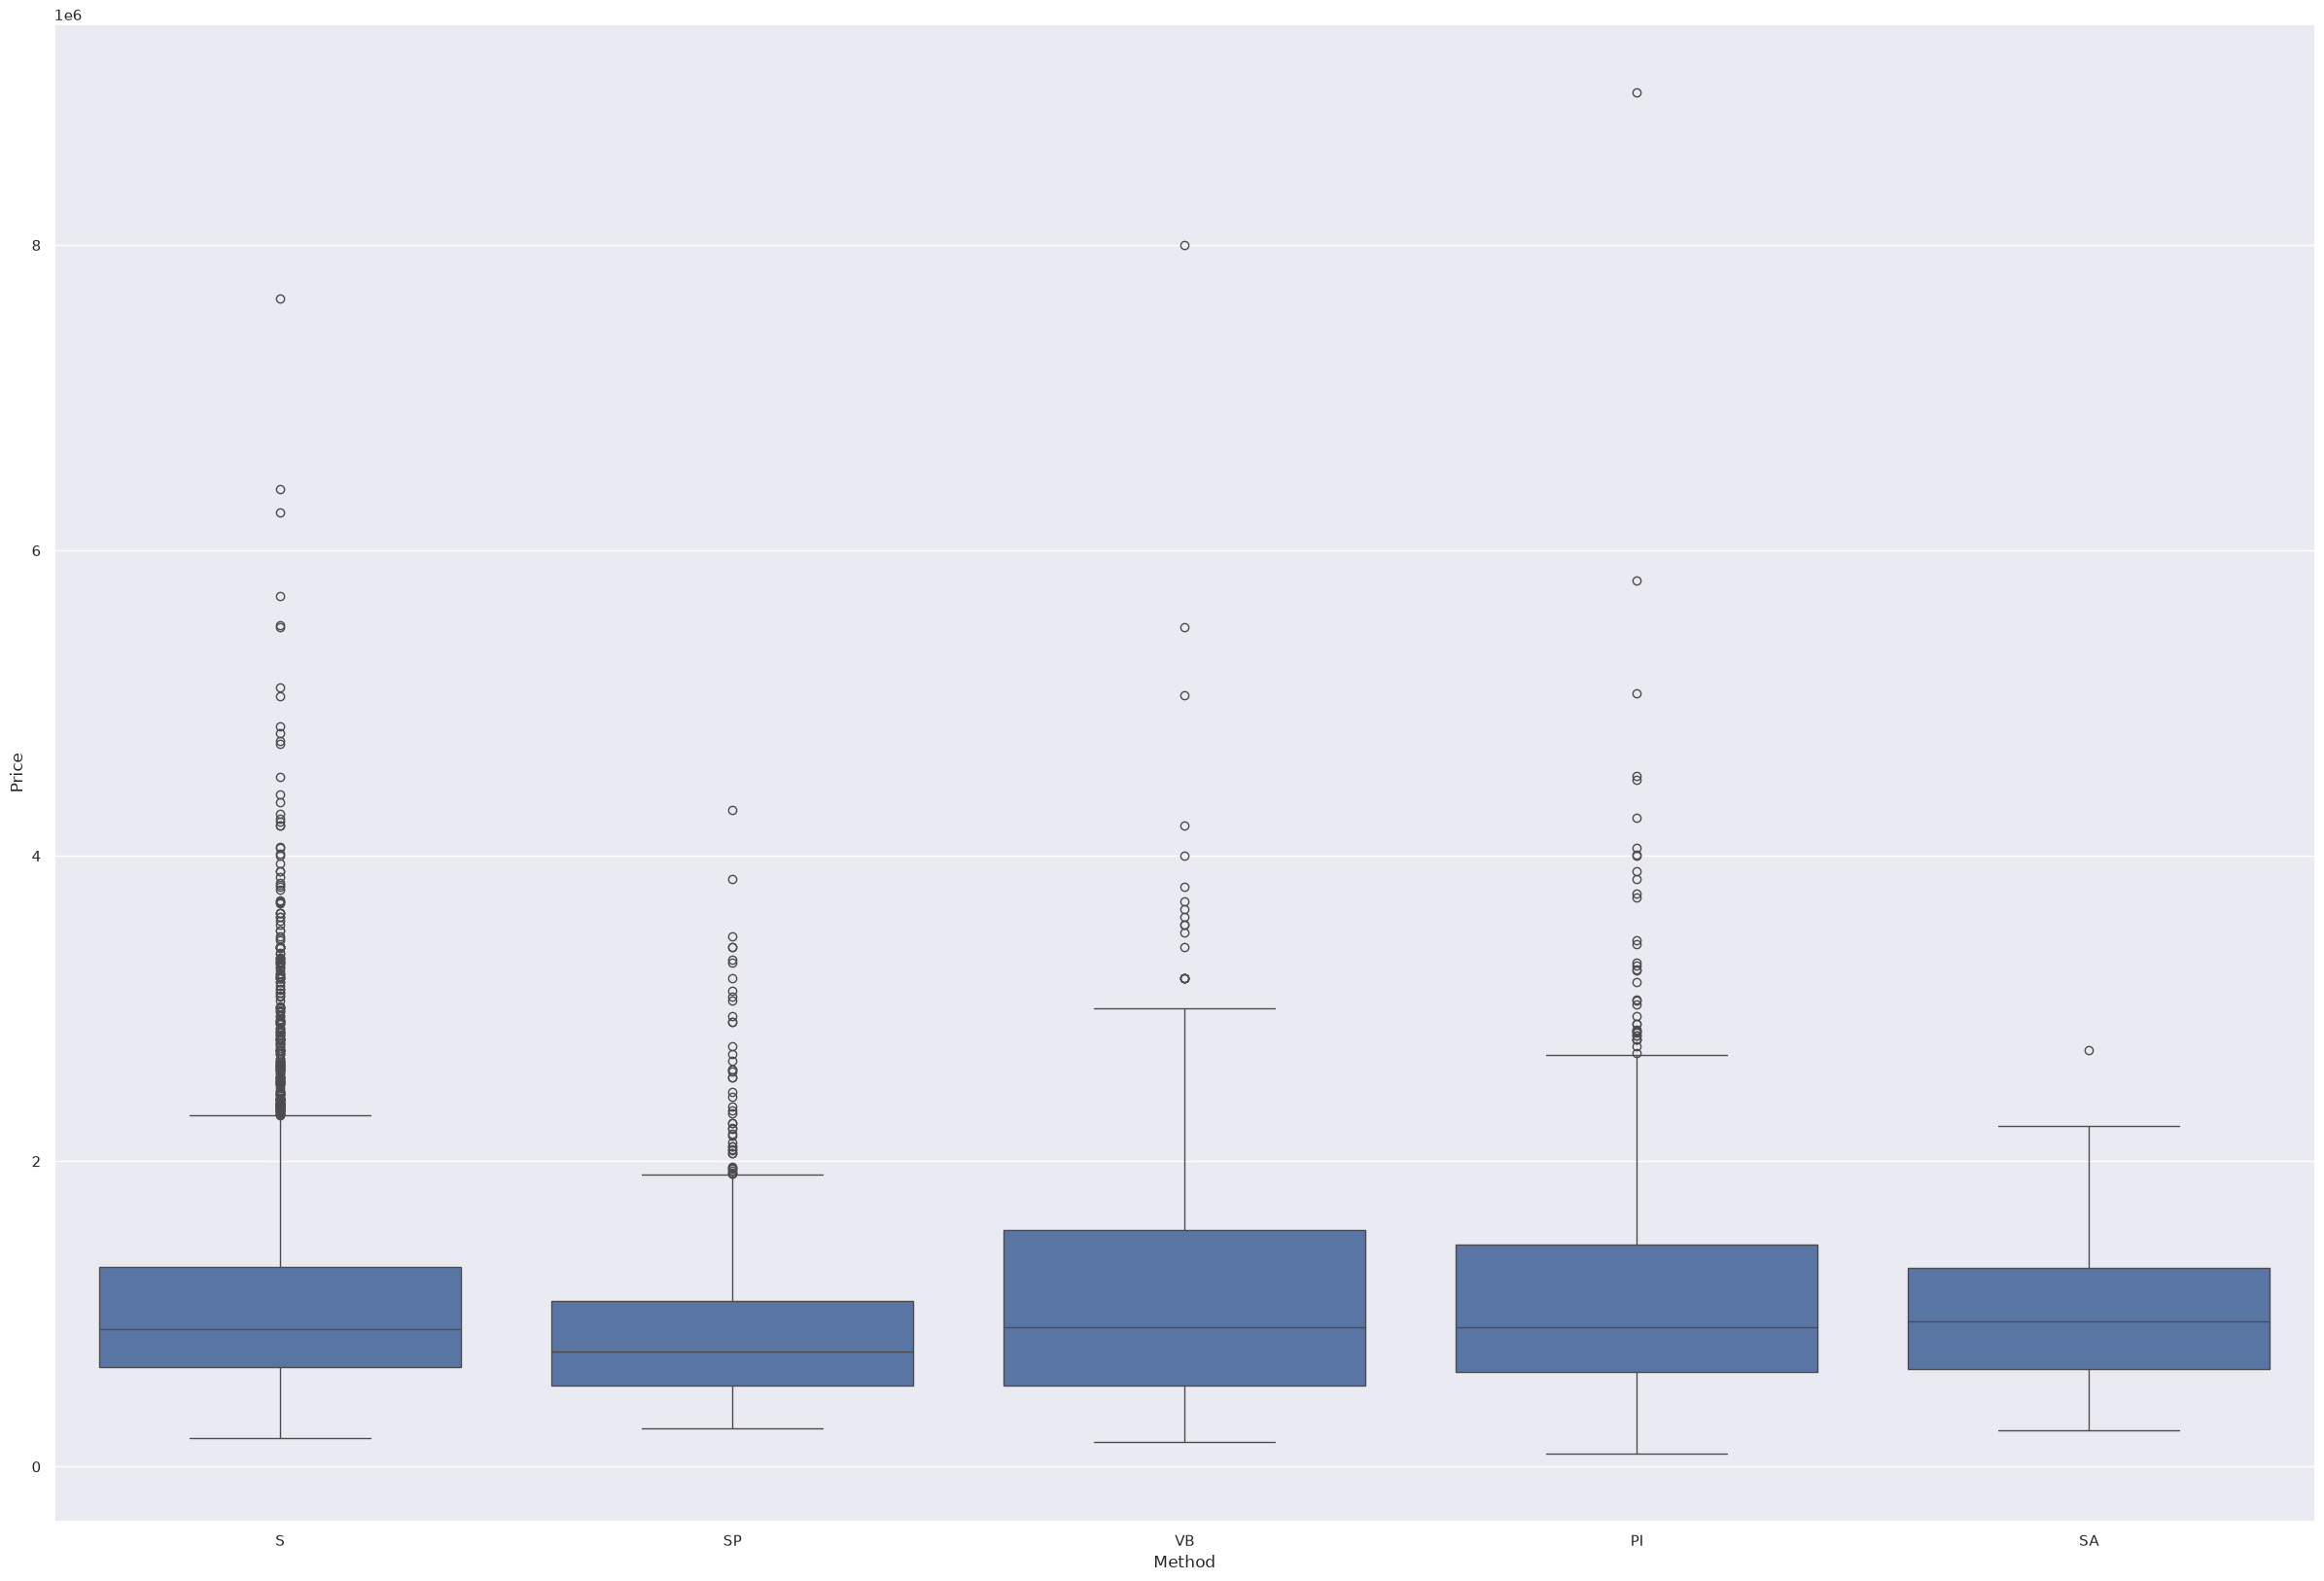

In [68]:
#boxplot on price on different methods by the house was sold
sns.set(rc={'figure.figsize':(30,20)})
ax = sns.boxplot(x="Method", y="Price", data=df)

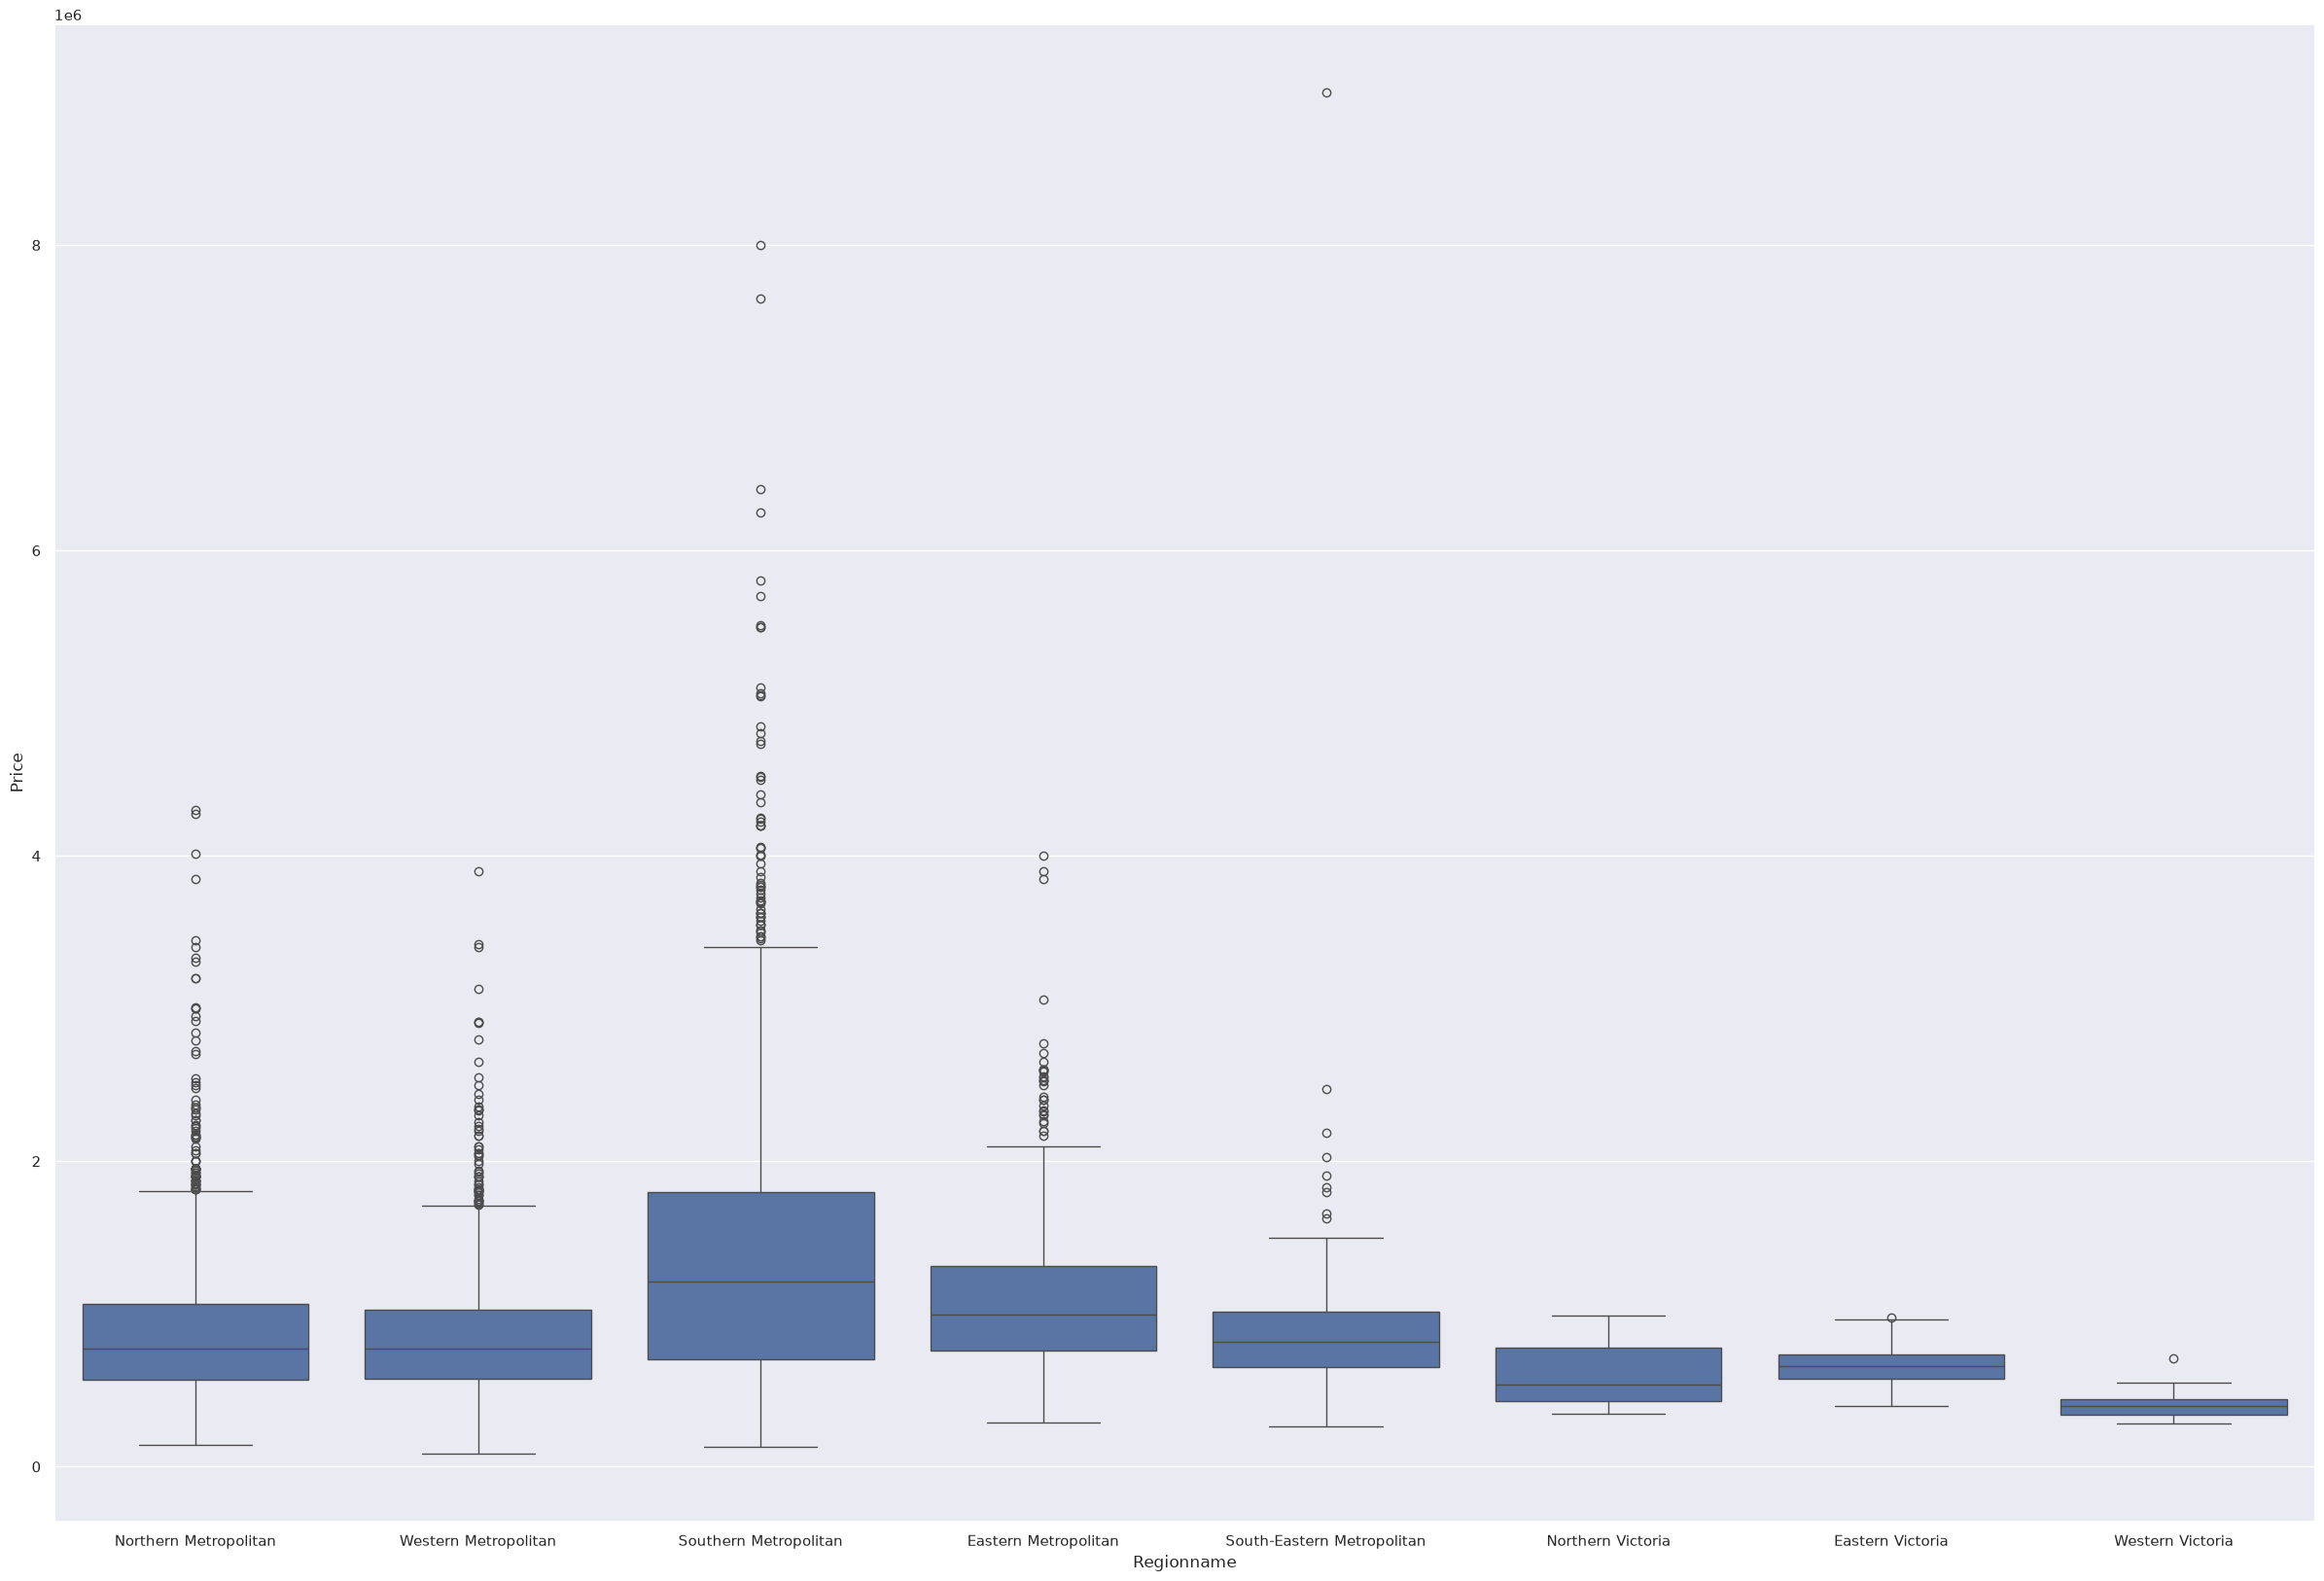

In [69]:
#boxplot on price on different regions across melbourne
sns.set(rc={'figure.figsize':(30,20)})
ax = sns.boxplot(x="Regionname", y="Price", data=df)

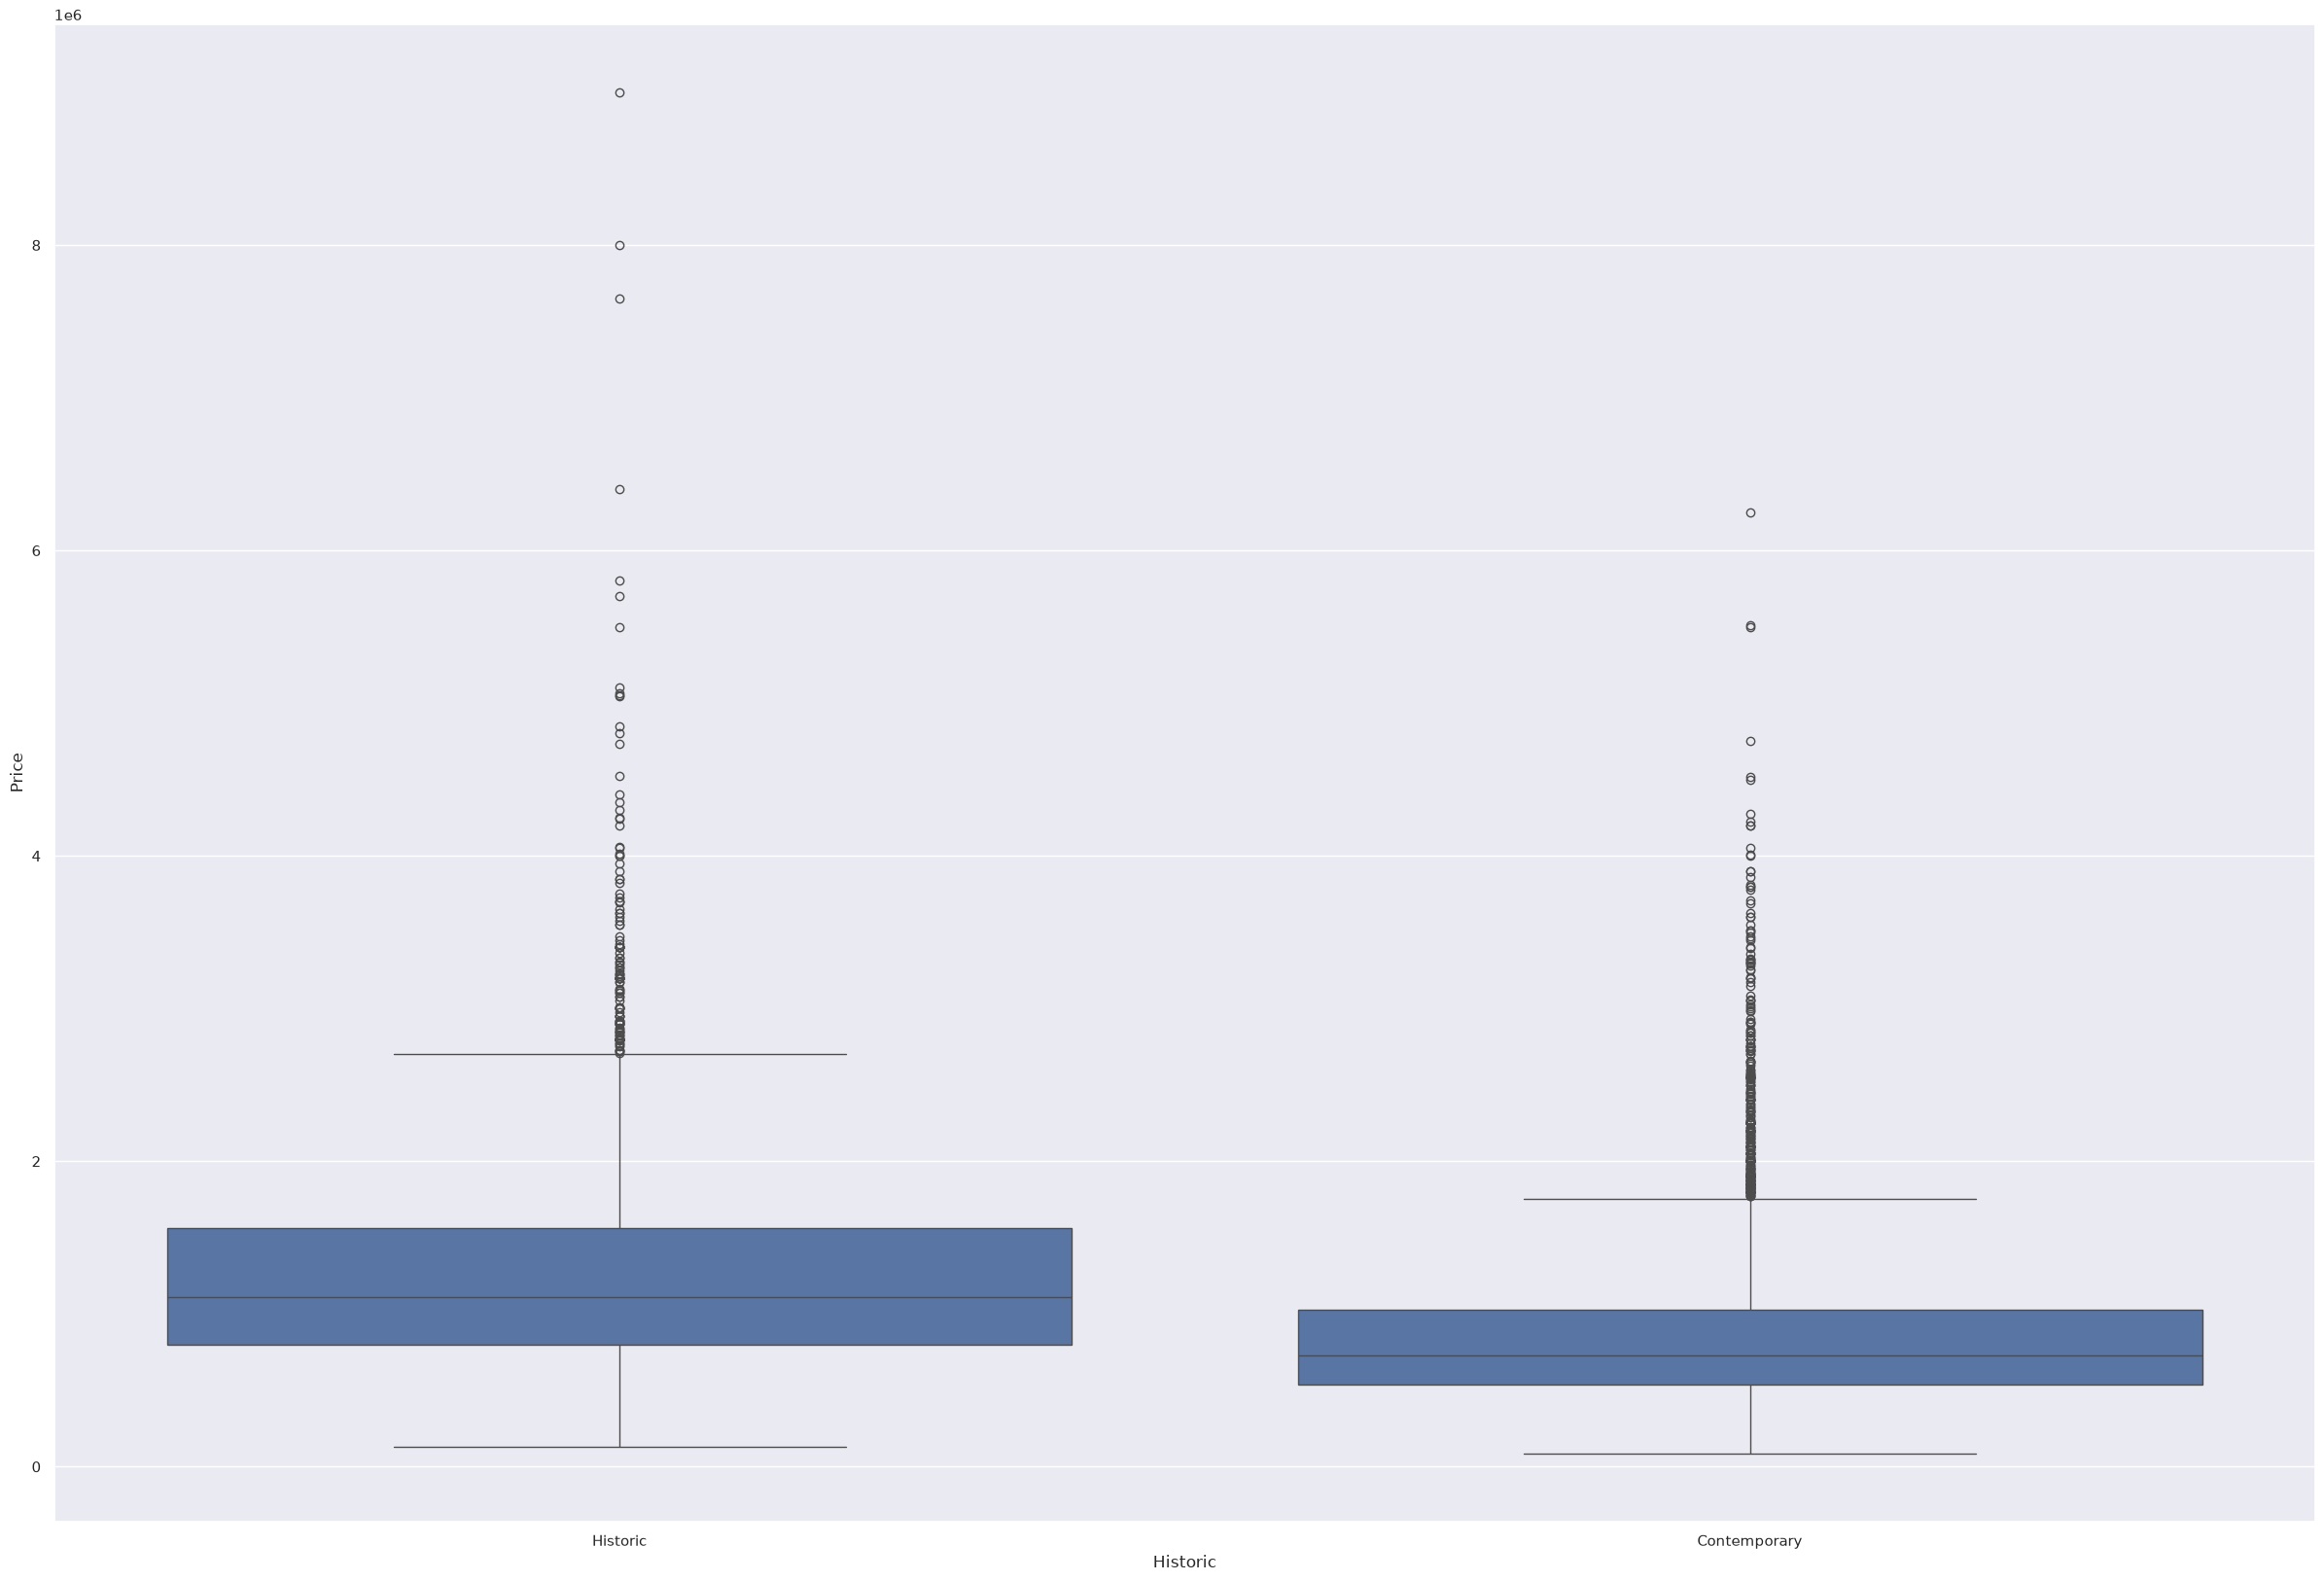

In [70]:
#boxplot on price on different timeline of building the house
sns.set(rc={'figure.figsize':(30,20)})
ax = sns.boxplot(x="Historic", y="Price", data=df)

## SCATTERPLOTS

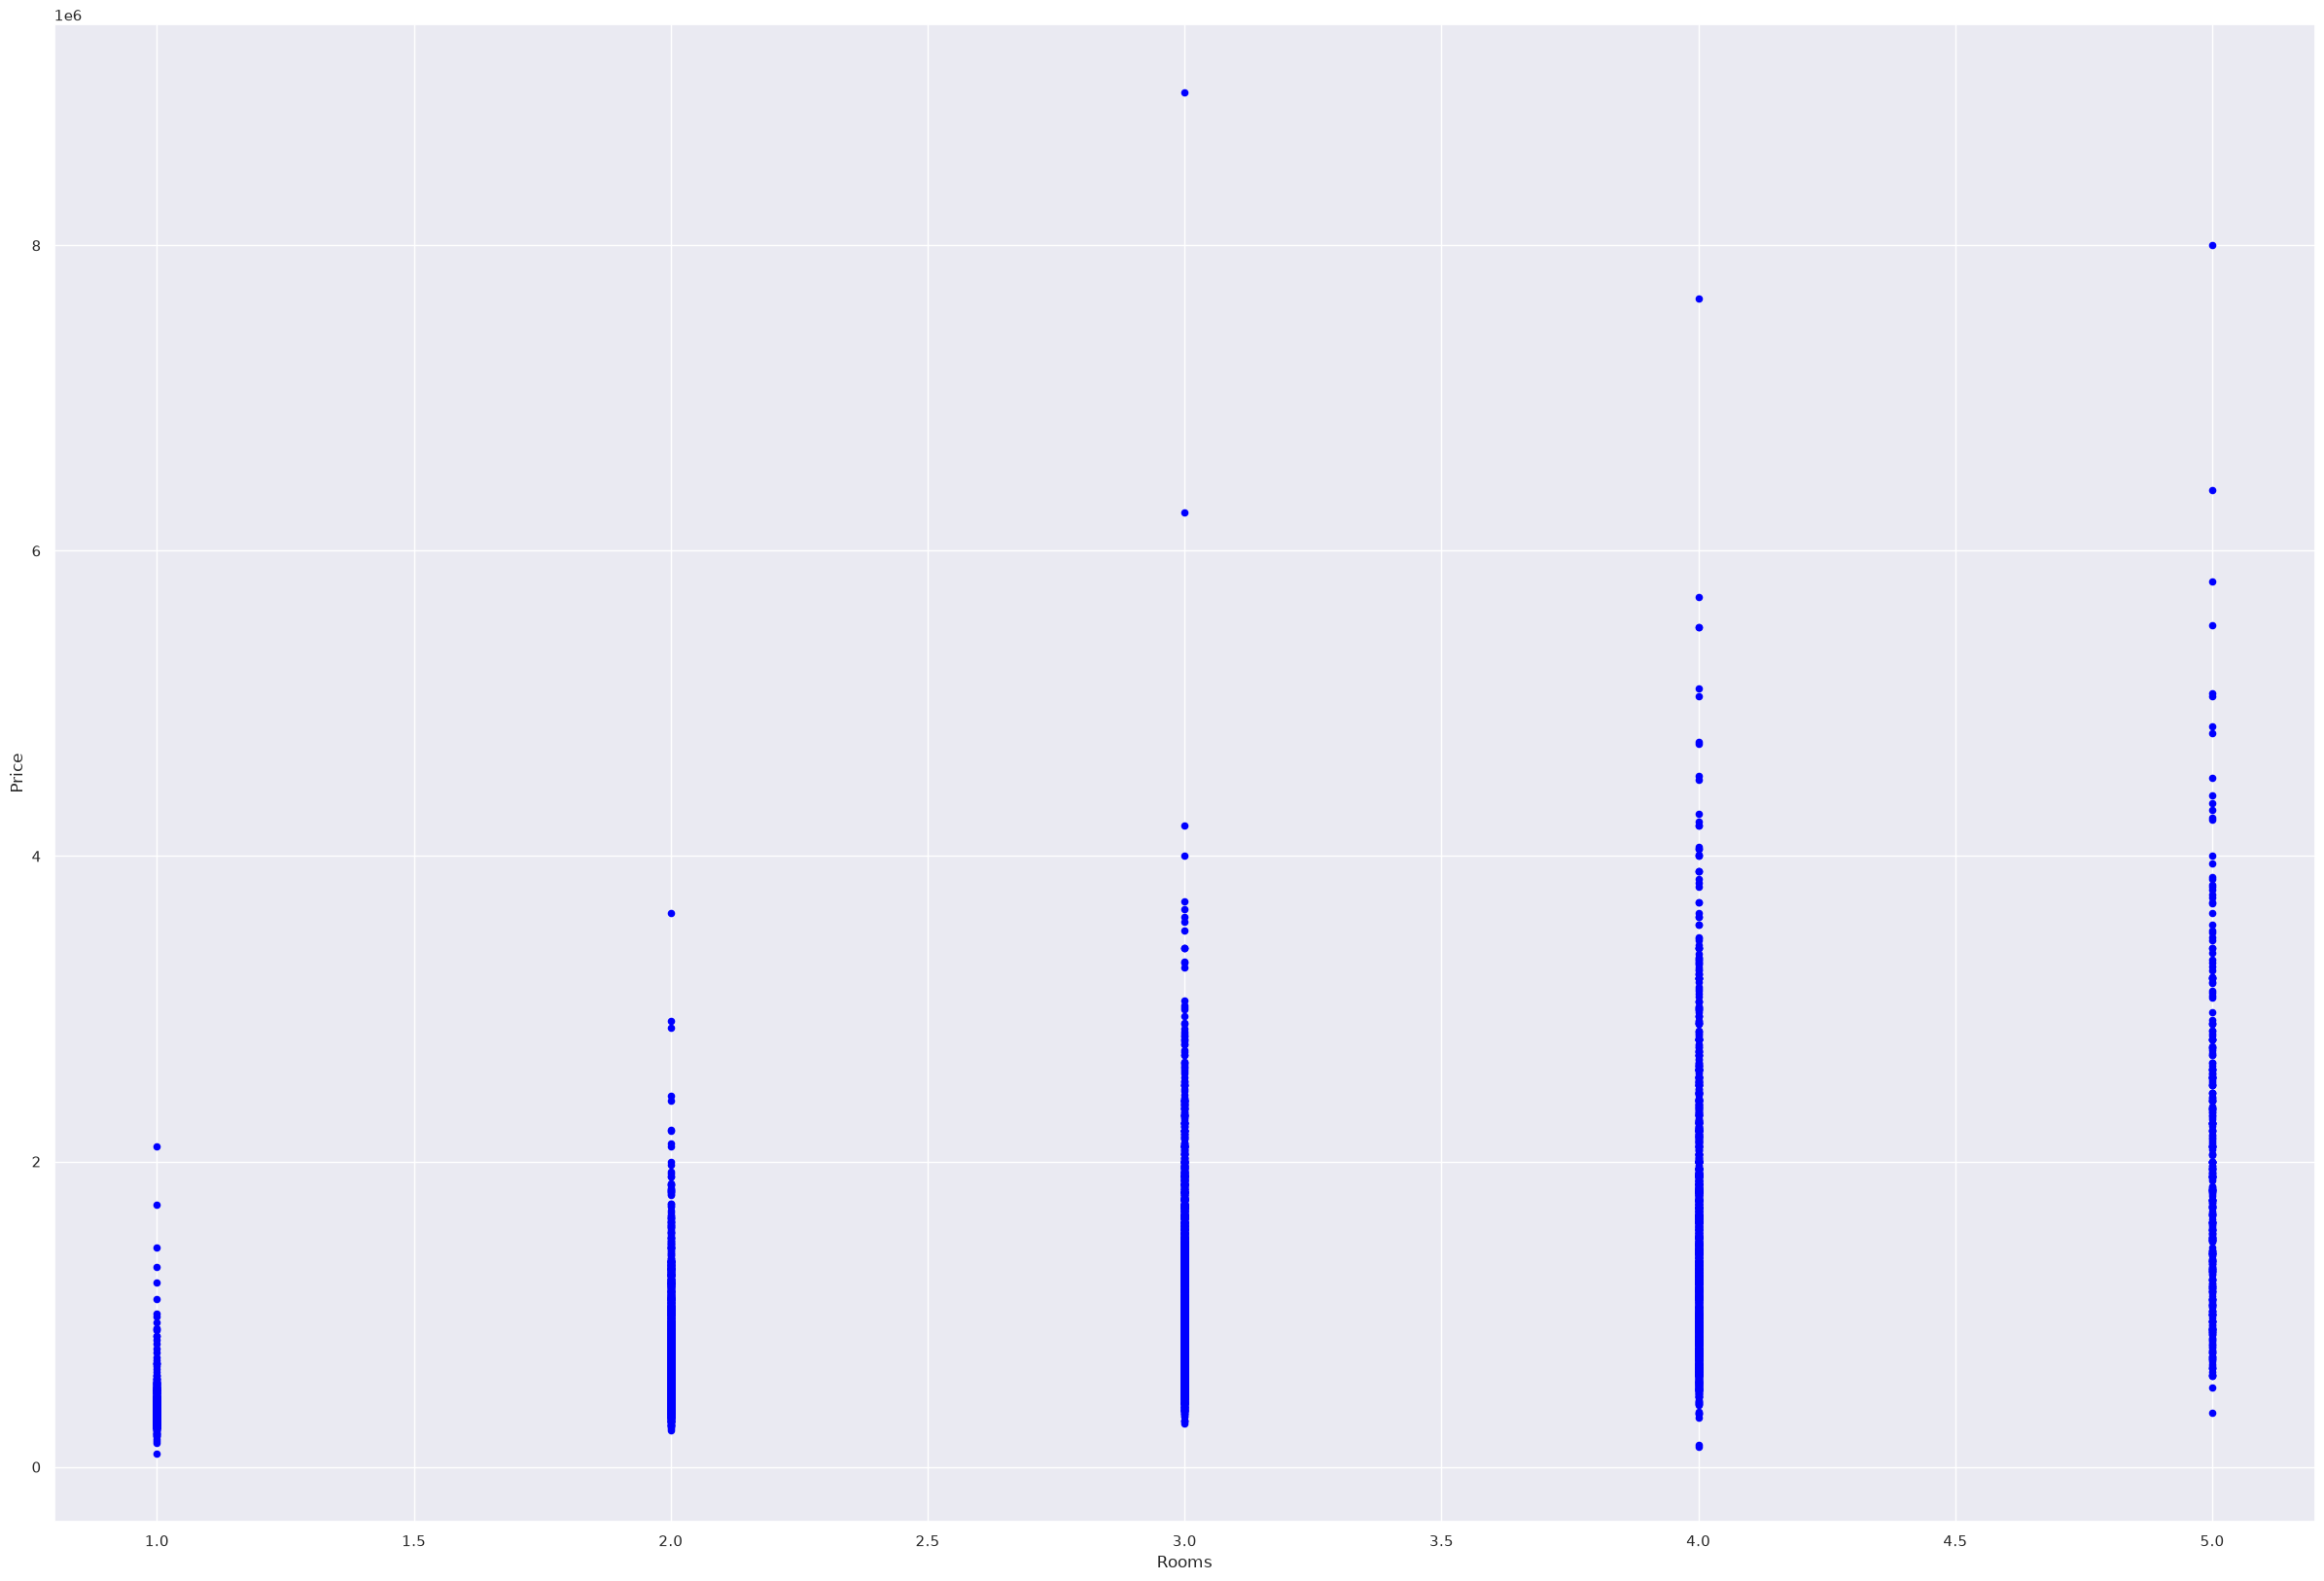

In [71]:
#scatterplot on rooms vs price for original dataset
ax2 = df.plot.scatter(x='Rooms',y='Price',c='blue')                      

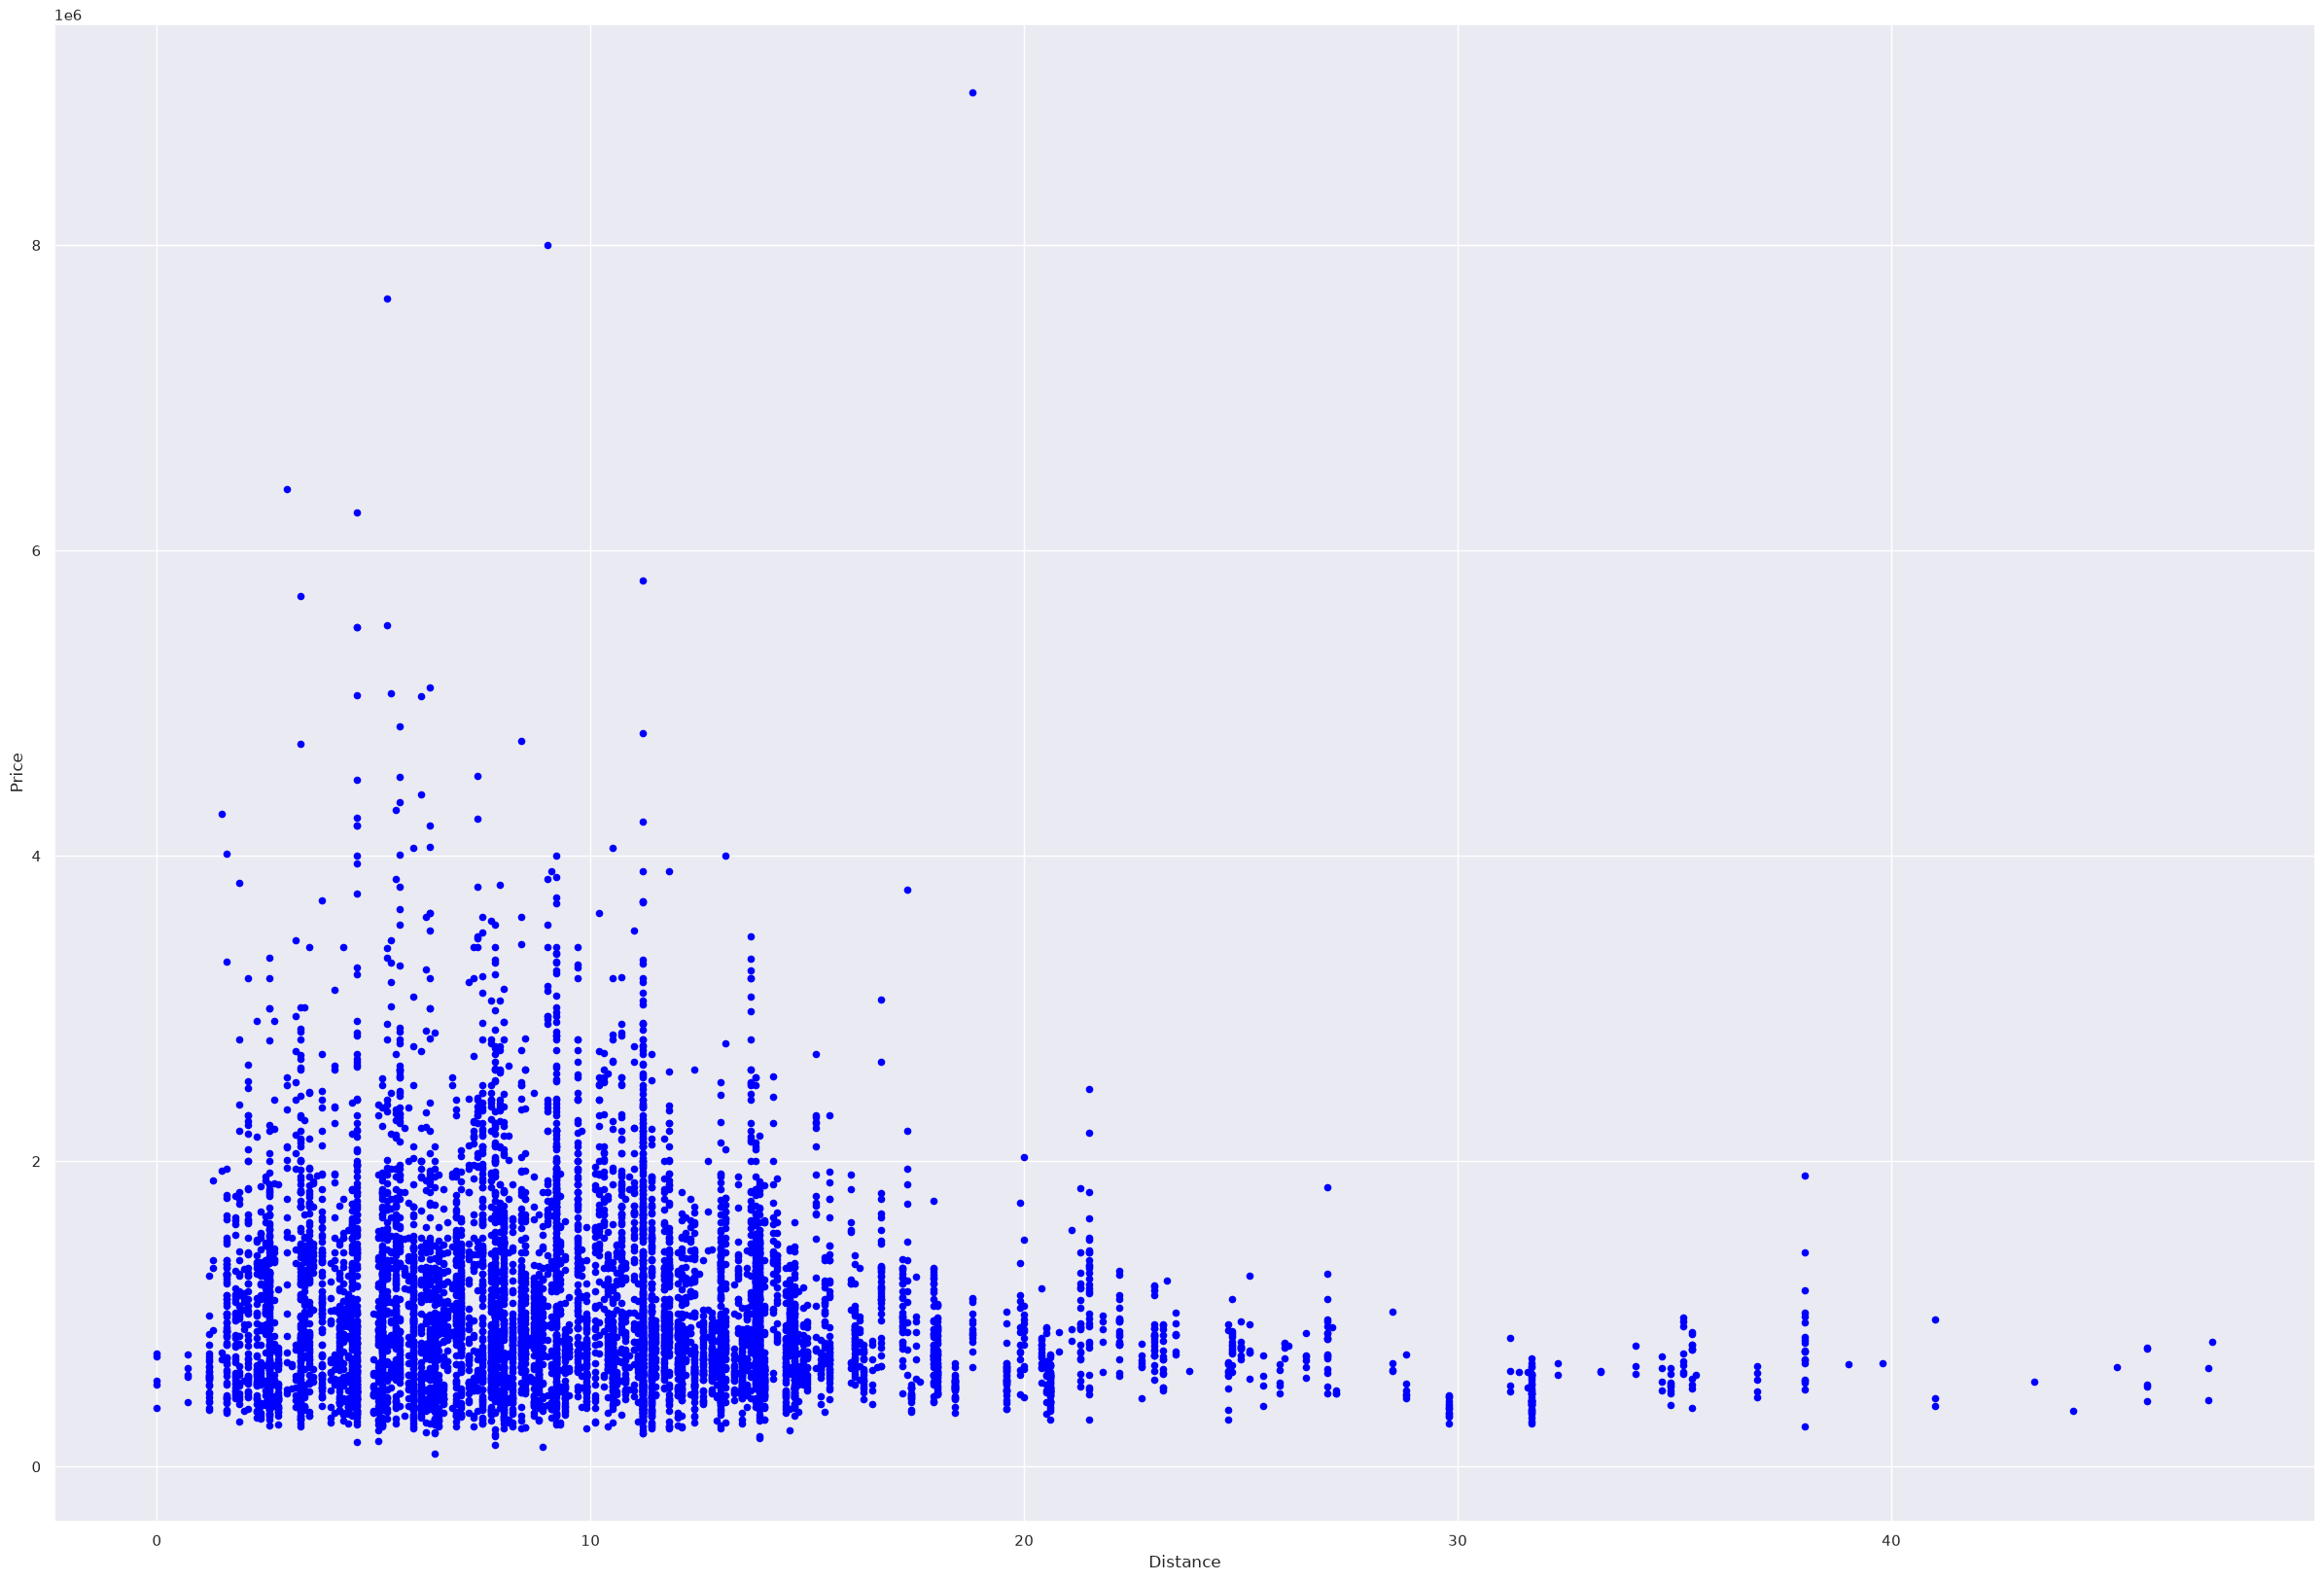

In [72]:
#scatterplot on DISTANCE vs price for original dataset
ax2 = df.plot.scatter(x='Distance',y='Price',c='blue')                      

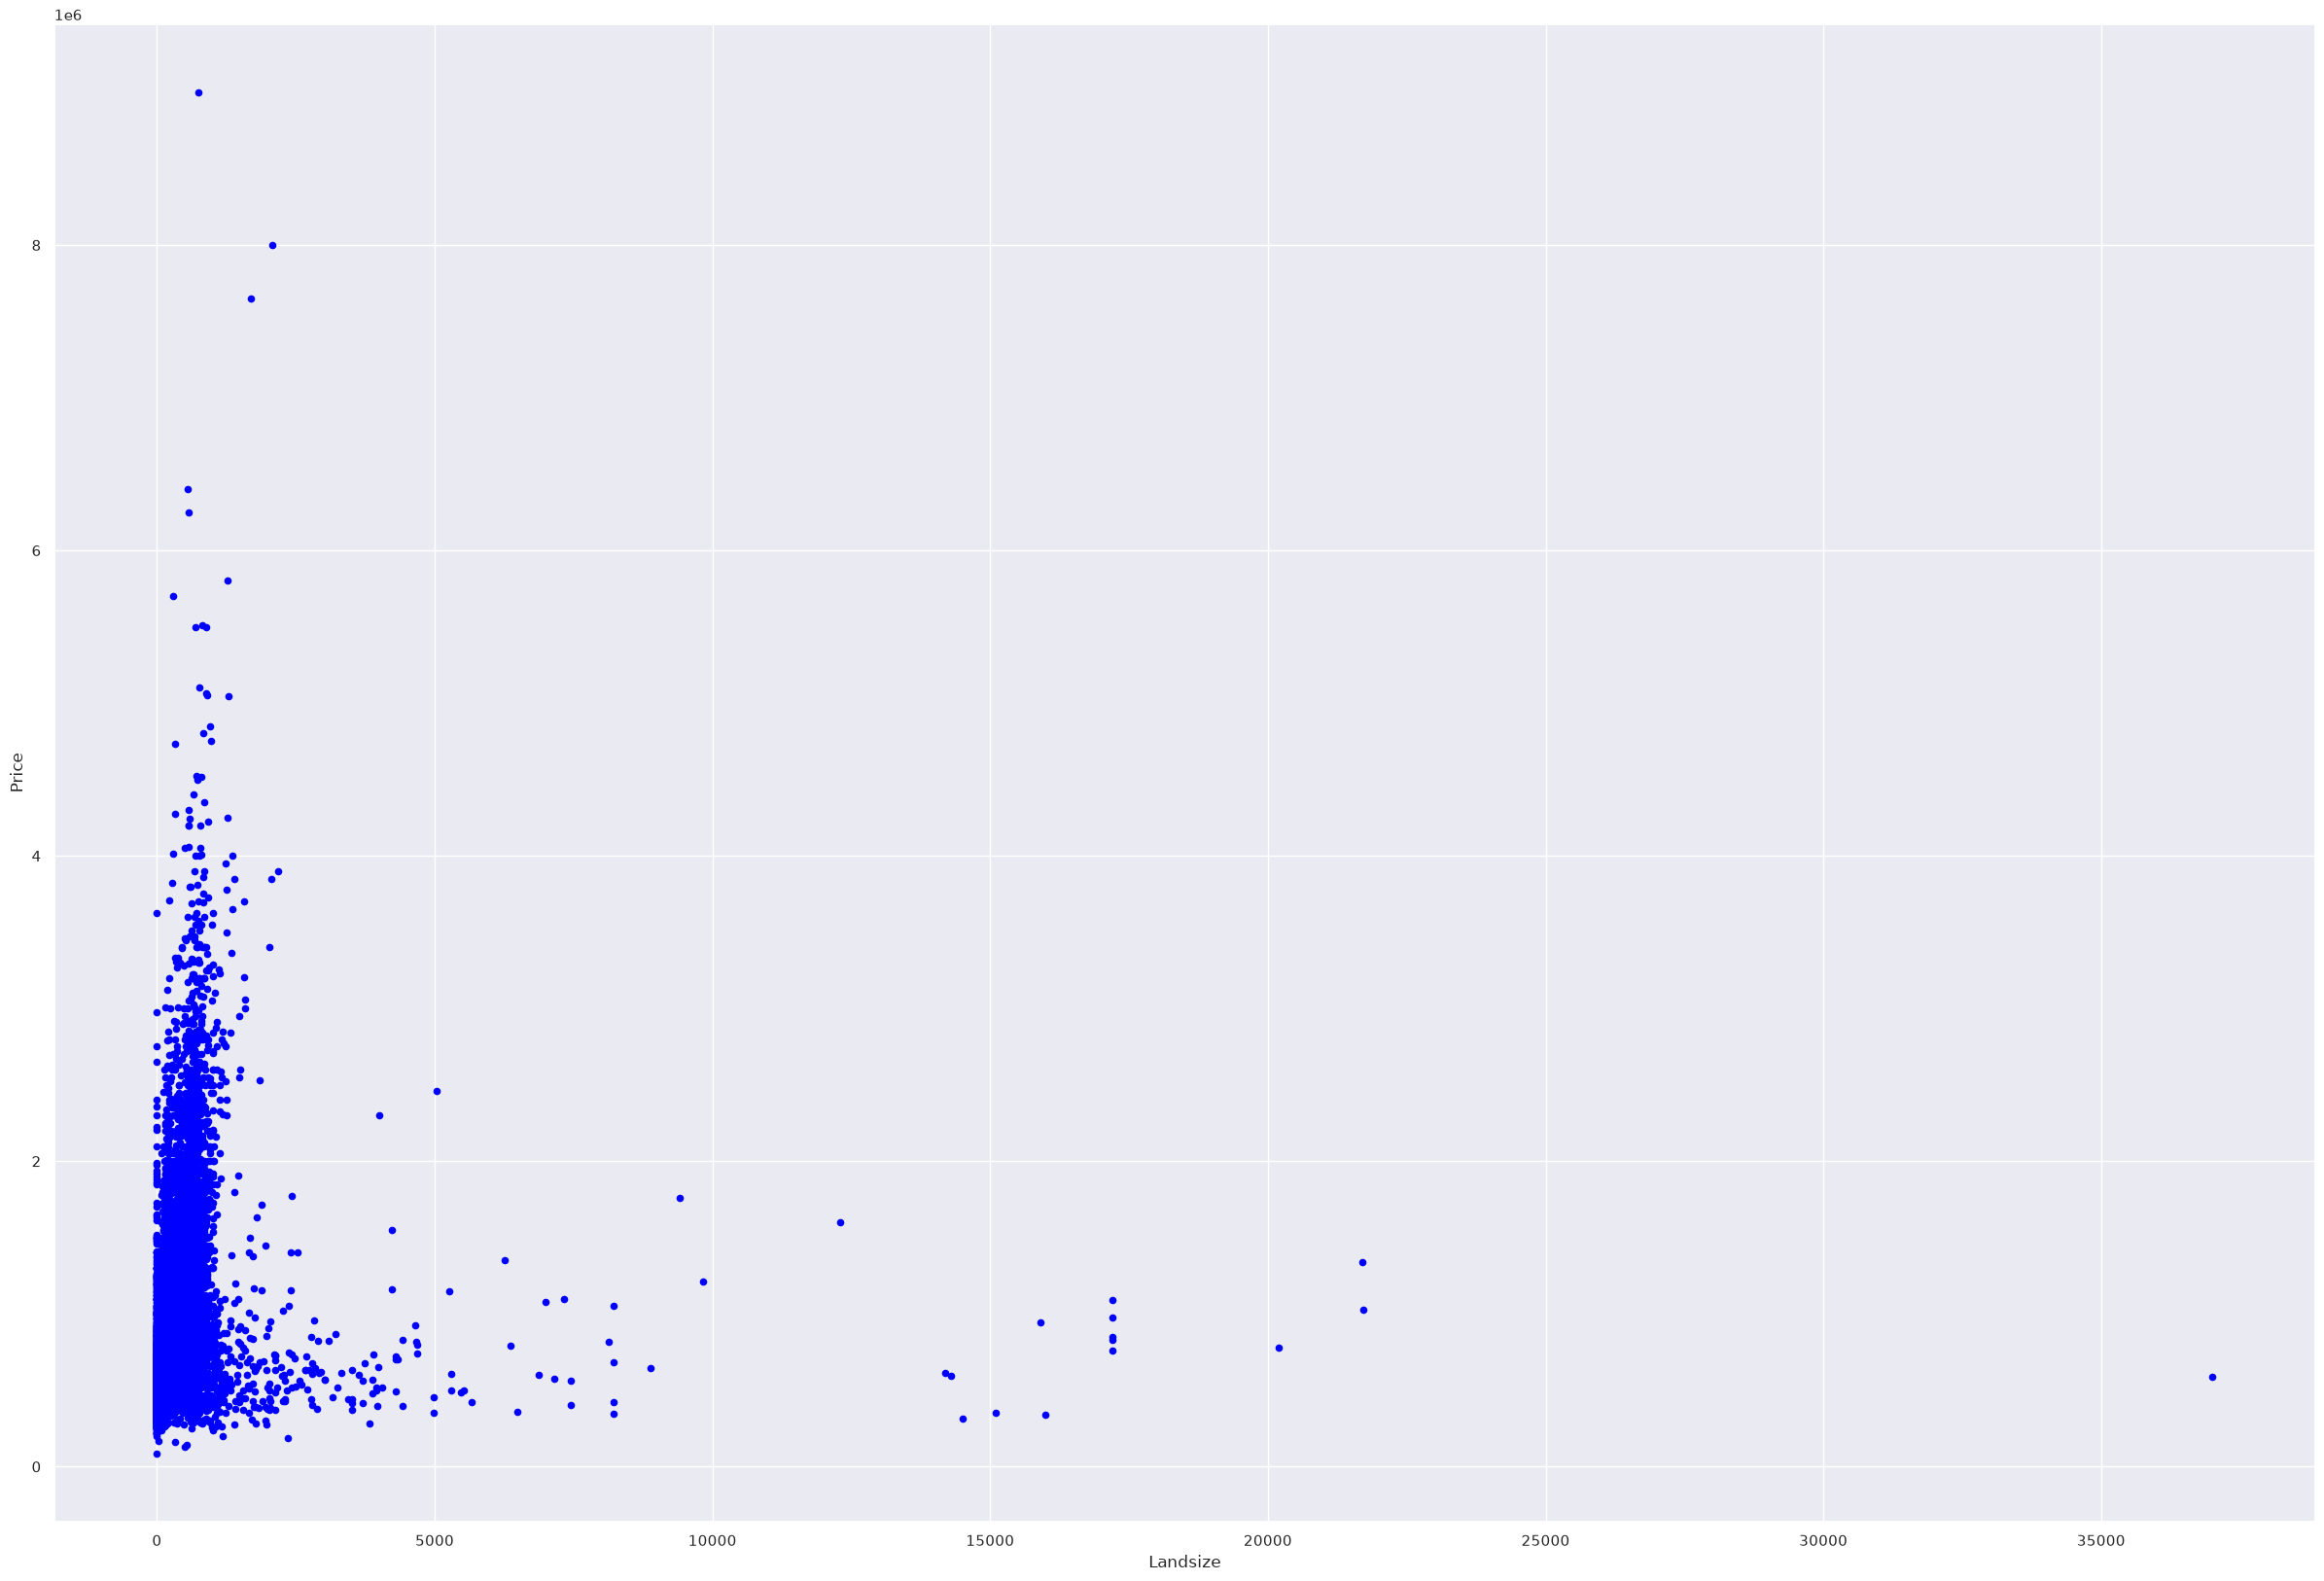

In [73]:
#scatterplot on landsize vs price for original dataset
ax2 = df.plot.scatter(x='Landsize',y='Price',c='blue')                      